In [20]:
%load_ext autoreload
%autoreload 2 
    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/spikewise')


from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup



from neurodsp import spectral

from scipy import signal
import scipy

import h5py
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

from neurodsp import filt
from neurodsp.timefrequency import amp_by_time, phase_by_time
from neurodsp.plts import plot_time_series, plot_instantaneous_measure
from neurodsp.plts.time_series import plot_bursts
from neurodsp.burst import detect_bursts_dual_threshold, compute_burst_stats

from scipy.signal import sosfiltfilt, butter

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import statsmodels.api as sm
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import MiniBatchKMeans



import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import scipy.stats as stats
import scipy.spatial as sp_spatial

import os
import time



from fooof import FOOOF

from sklearn.linear_model import LinearRegression

sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})


import warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'

### HELPER FUNCTIONS - to do: move to .py file 

In [22]:
def butter_bandpass(data, fs, filt_freq, order):
    # make sure that the user provides two frequencies for bandpass filter
    try:
        # renormalize frequencies in Hz to fractional scale required by butter
        nyq = 0.5 * fs # nyquist frequency
        f0 = (filt_freq[0]/nyq)
        f1 = (filt_freq[1]/nyq)

        # highpass first
        sos = butter(order, f0, btype = 'high', analog=False, output='sos')
        y = sosfiltfilt(sos, data)

        # then lowpass
        sos = butter(order, f1, btype = 'low', analog=False, output='sos')
        y = sosfiltfilt(sos, y)
        
        return y
    
    except:
        print("filt_freq must have two frequencies for a bandpass filter")

In [23]:
def get_patch_fs_metadata(metadata_file, cell_num):
    
    metafile = pd.read_excel(metadata_file, sheet_name='Sheet1')
    #get index for cell
    cells = metafile['Cell']
    index_cell = cells[cells == "c"+str(cell_num)].index[0]
    
    #get path fs for cell
    
    patch_fs = metafile['Patch Samp. Freq. (Hz)'][index_cell]
    
    return patch_fs
    

In [24]:
def upper(df):
    '''Returns the upper triangle of a correlation matrix.
    You can use scipy.spatial.distance.squareform to recreate matrix from upper triangle.
    Args:
      df: pandas or numpy correlation matrix
    Returns:
      list of values from upper triangle
    '''
    try:
        assert(type(df)==np.ndarray)
    except:
        if type(df)==pd.DataFrame:
            df = df.values
        else:
            raise TypeError('Must be np.ndarray or pd.DataFrame')
    mask = np.triu_indices(df.shape[0], k=1)
    return df[mask]

In [25]:
metadata_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Data Summary.xlsx'
patch_fs_c7 = 50023.9136116689


In [26]:
npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate


npx_channels = 374
npx_patch_channel = 161

data_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/'

out_lfp_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/'

out_npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'

out_patch_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/'

cell_ids = ['c7', 'c7']

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook 

#load_spe1_data(data_path, lfp_fs, npx_fs, patch_fs, cell_ids, npx_channels, npx_patch_channel, out_lfp_path, out_npx_path, out_patch_path)



## Cell 7  (Whole patch, IC)
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 7

#### Step 0: Get loaded data

In [27]:
lfp_c7= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c7_lfp_filt.npy'
patch_c7 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c7patch_filt.npy'


In [28]:
#get cell number 
cell_num = lfp_c7.split('/')[len(lfp_c7.split('/'))-1].split('_')[0]


#get patch data 
patch_filt_c7 = np.load(patch_c7)
patch_c7_one_ms = float(patch_fs_c7  / 1000)
patch_times_c7 = np.arange(0, np.shape(patch_filt_c7 )[0]) / patch_c7_one_ms # in ms instead of sec

### Compute patch clamp spike features for cell 7

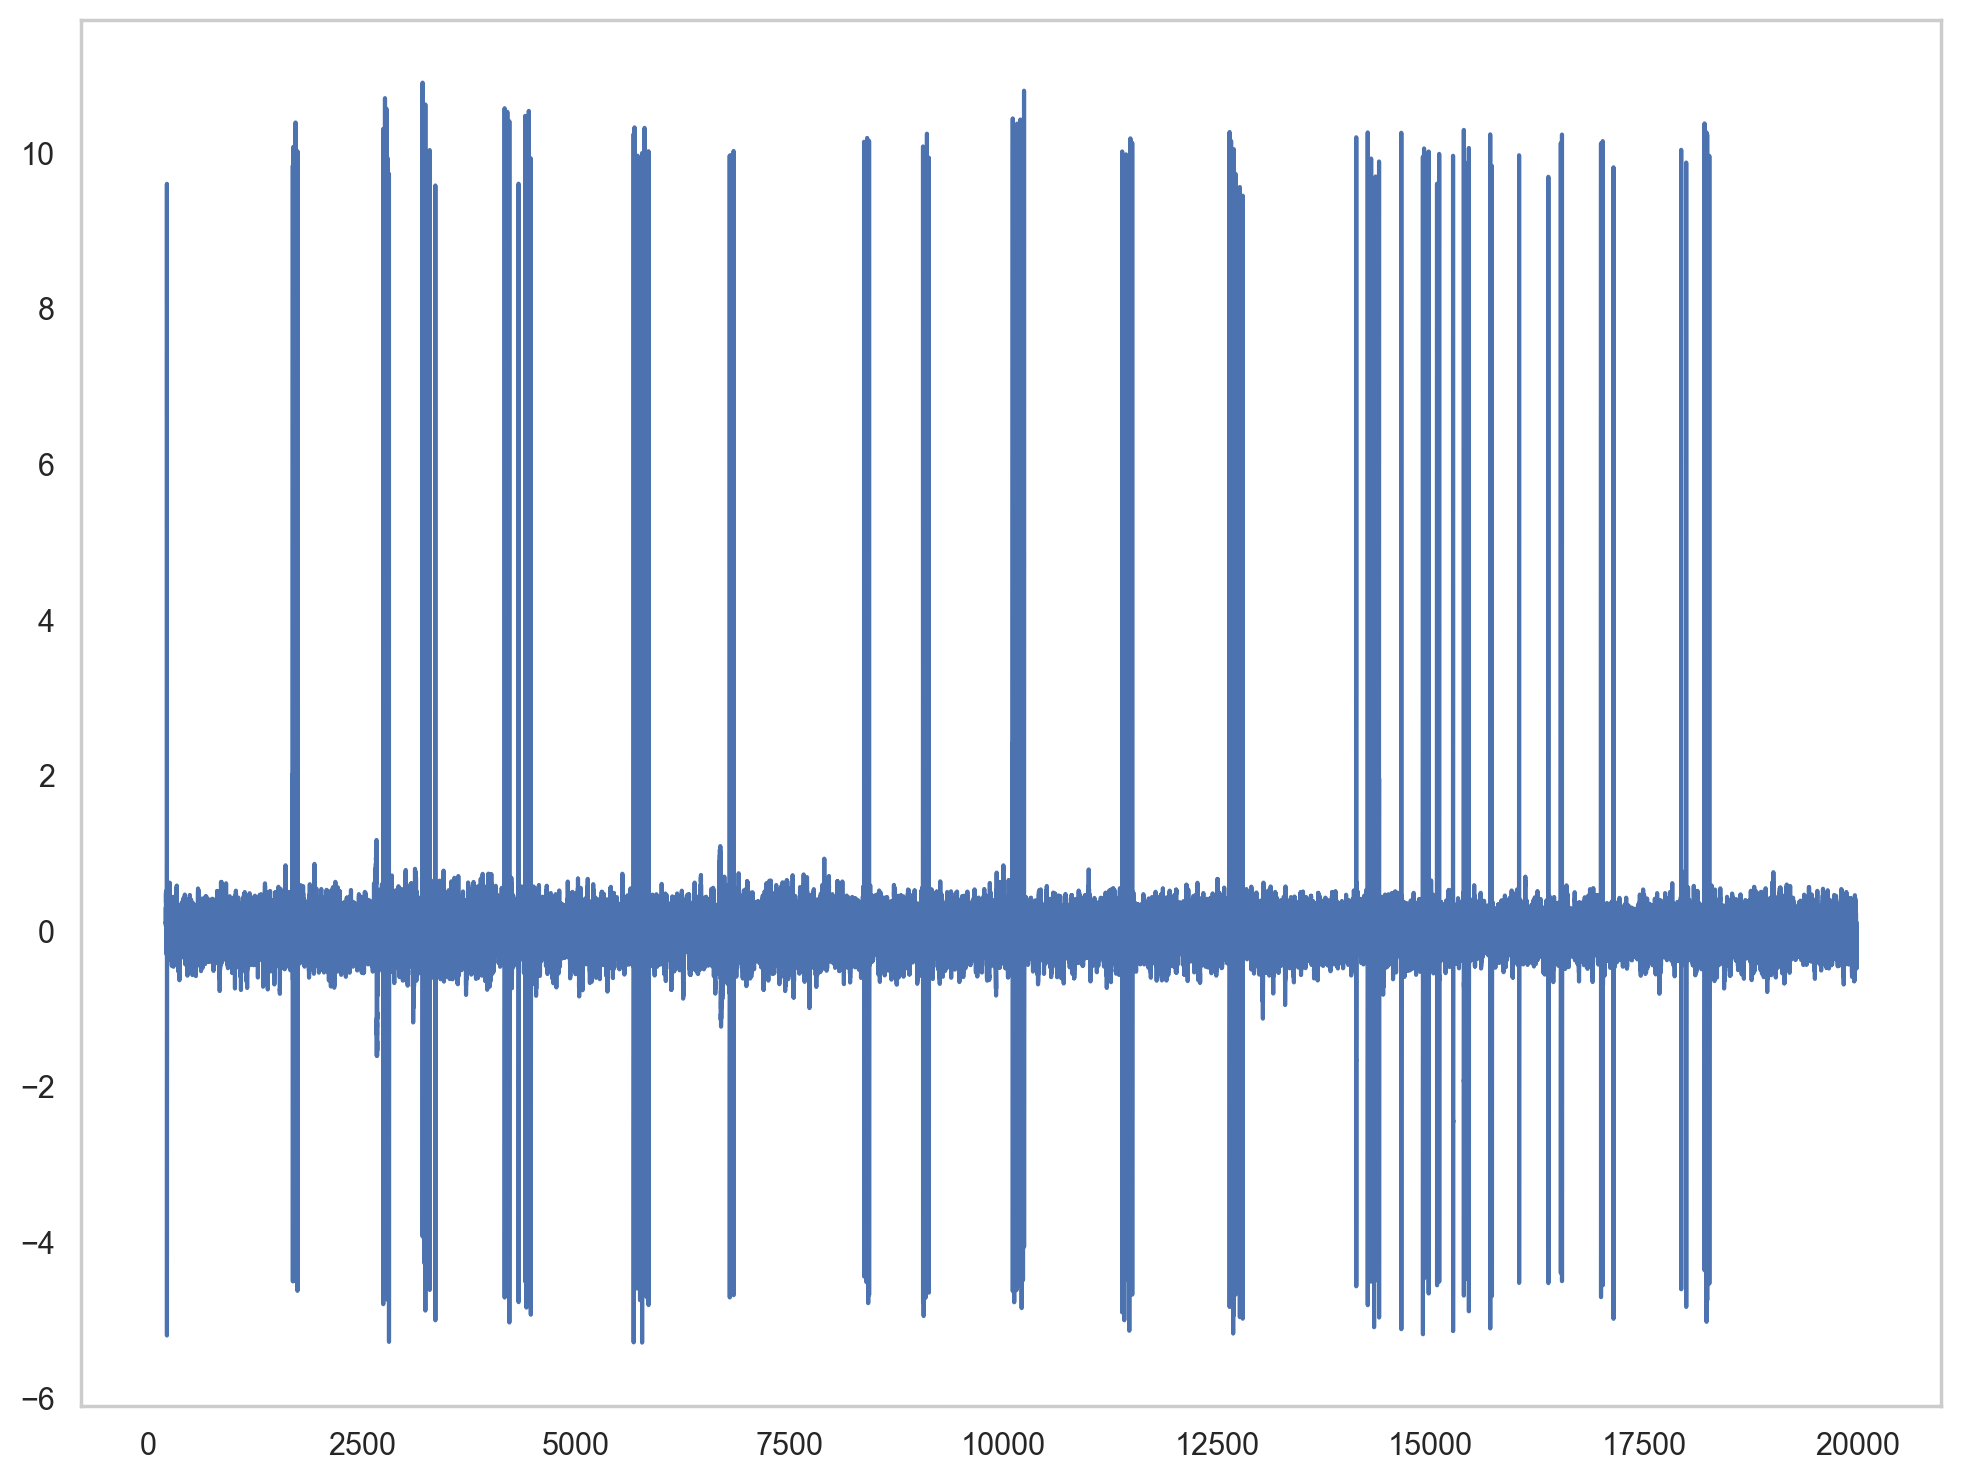

In [29]:
plt.plot(patch_times_c7[10000:1000000], patch_filt_c7[10000:1000000])

In [30]:
def compute_alt_features(stim, fs):
    return stim.mean(), stim.std()

#threshold in mVs
sp = Spike(thresh_amp=3.41, window_length=(5., 5.), smooth_frac=.01)

"""sp.alt(lfp_filt_c7, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))"""

sp.fit(patch_filt_c7, patch_fs_c7, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/7724 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [31]:
sp.df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp
0,0.474264,0.24,0.746710,10.054835,0.20,4.348924,0.000005,-0.591083,25.667724,0.549251,0.562543
1,0.545998,0.24,0.801151,10.107197,0.20,4.240914,0.000008,-0.563377,26.147494,0.870447,0.510640
2,0.273069,0.26,0.496558,9.834023,0.20,4.561204,0.000029,-0.650551,26.747208,0.696417,0.590927
3,0.352517,0.26,0.618058,10.383387,0.20,4.729567,0.000006,-0.516180,49.896136,0.897097,0.582699
4,0.372451,0.24,0.523570,9.435862,0.20,4.196835,0.000011,-0.735128,23.608709,0.856181,0.493065
...,...,...,...,...,...,...,...,...,...,...,...
7719,0.901338,0.36,0.541072,10.369670,0.26,3.097858,0.000014,-0.340859,27.306940,0.921629,0.443141
7720,0.281532,0.36,0.347986,9.838371,0.28,3.035007,0.000001,-0.550902,515.373511,0.646742,0.558165
7721,0.434855,0.36,0.333378,10.521761,0.26,3.371638,0.000049,-0.769832,137.214374,0.745559,0.684400
7722,0.609430,0.34,0.519964,10.741164,0.24,3.539253,0.000005,-0.738905,40.620572,0.858267,0.554418


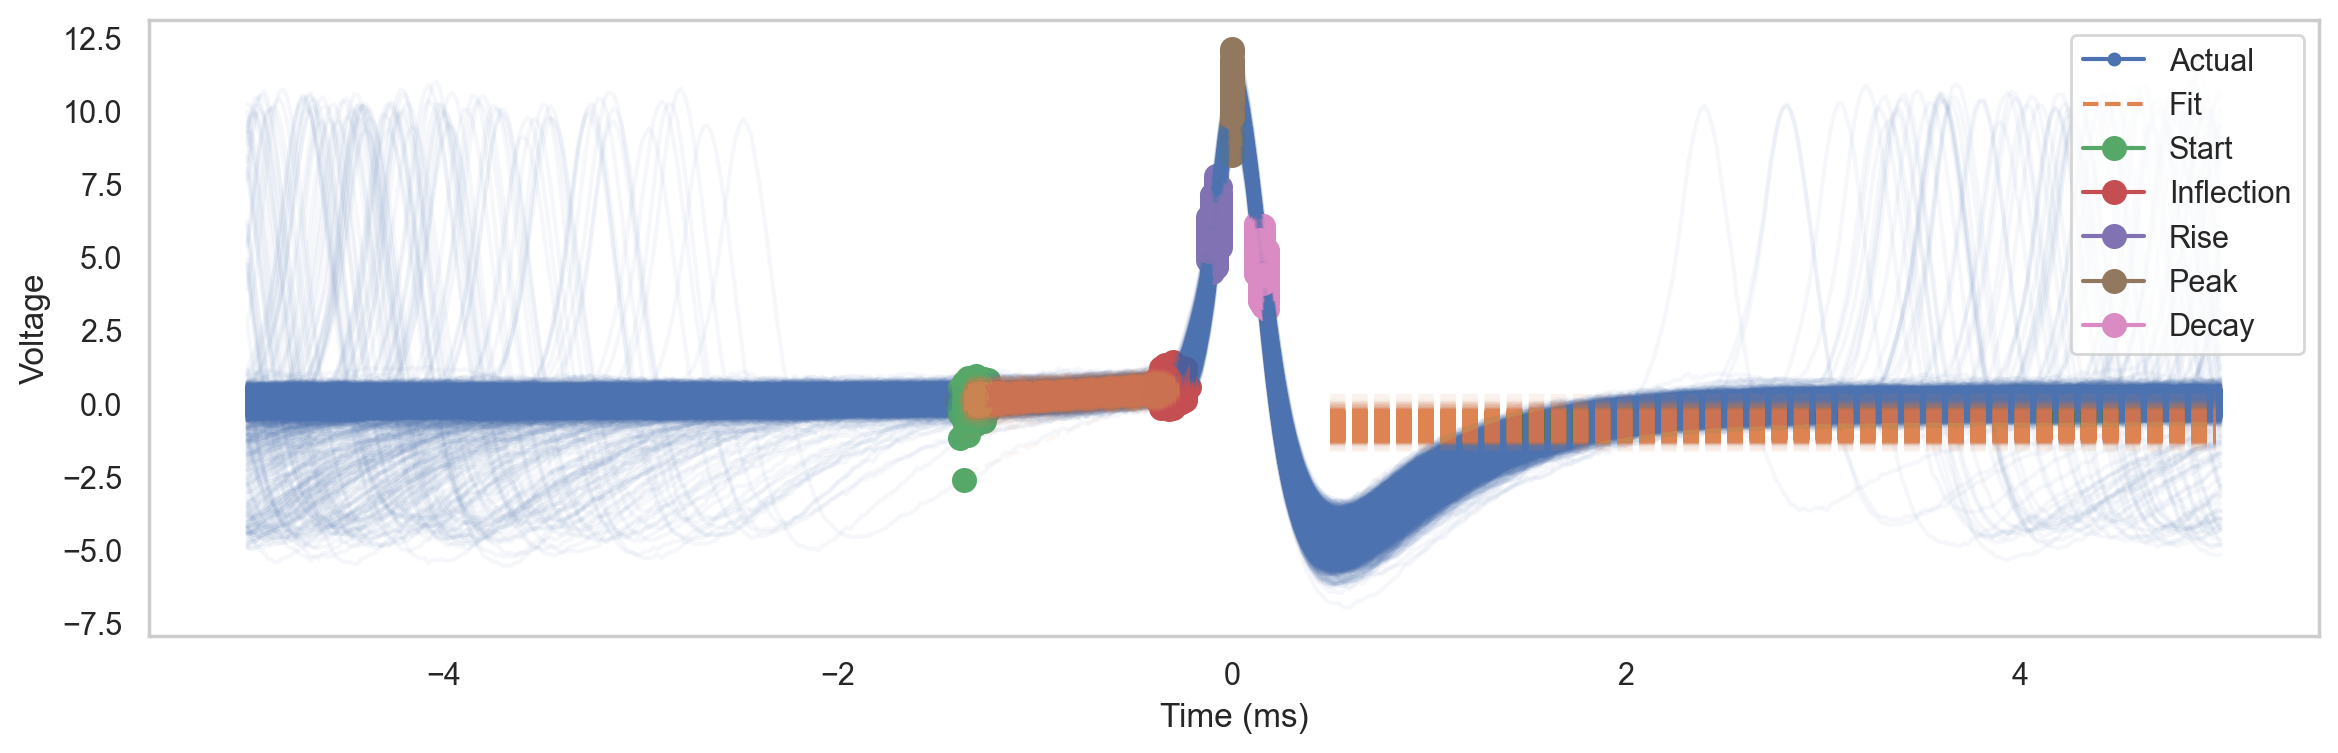

In [32]:
sp.plot(show_points=True)

#### Plot correlations 

In [33]:
df_features = sp.df_features
# Add an index column to df_features to maintain original indices
df_features['original_index'] = df_features.index



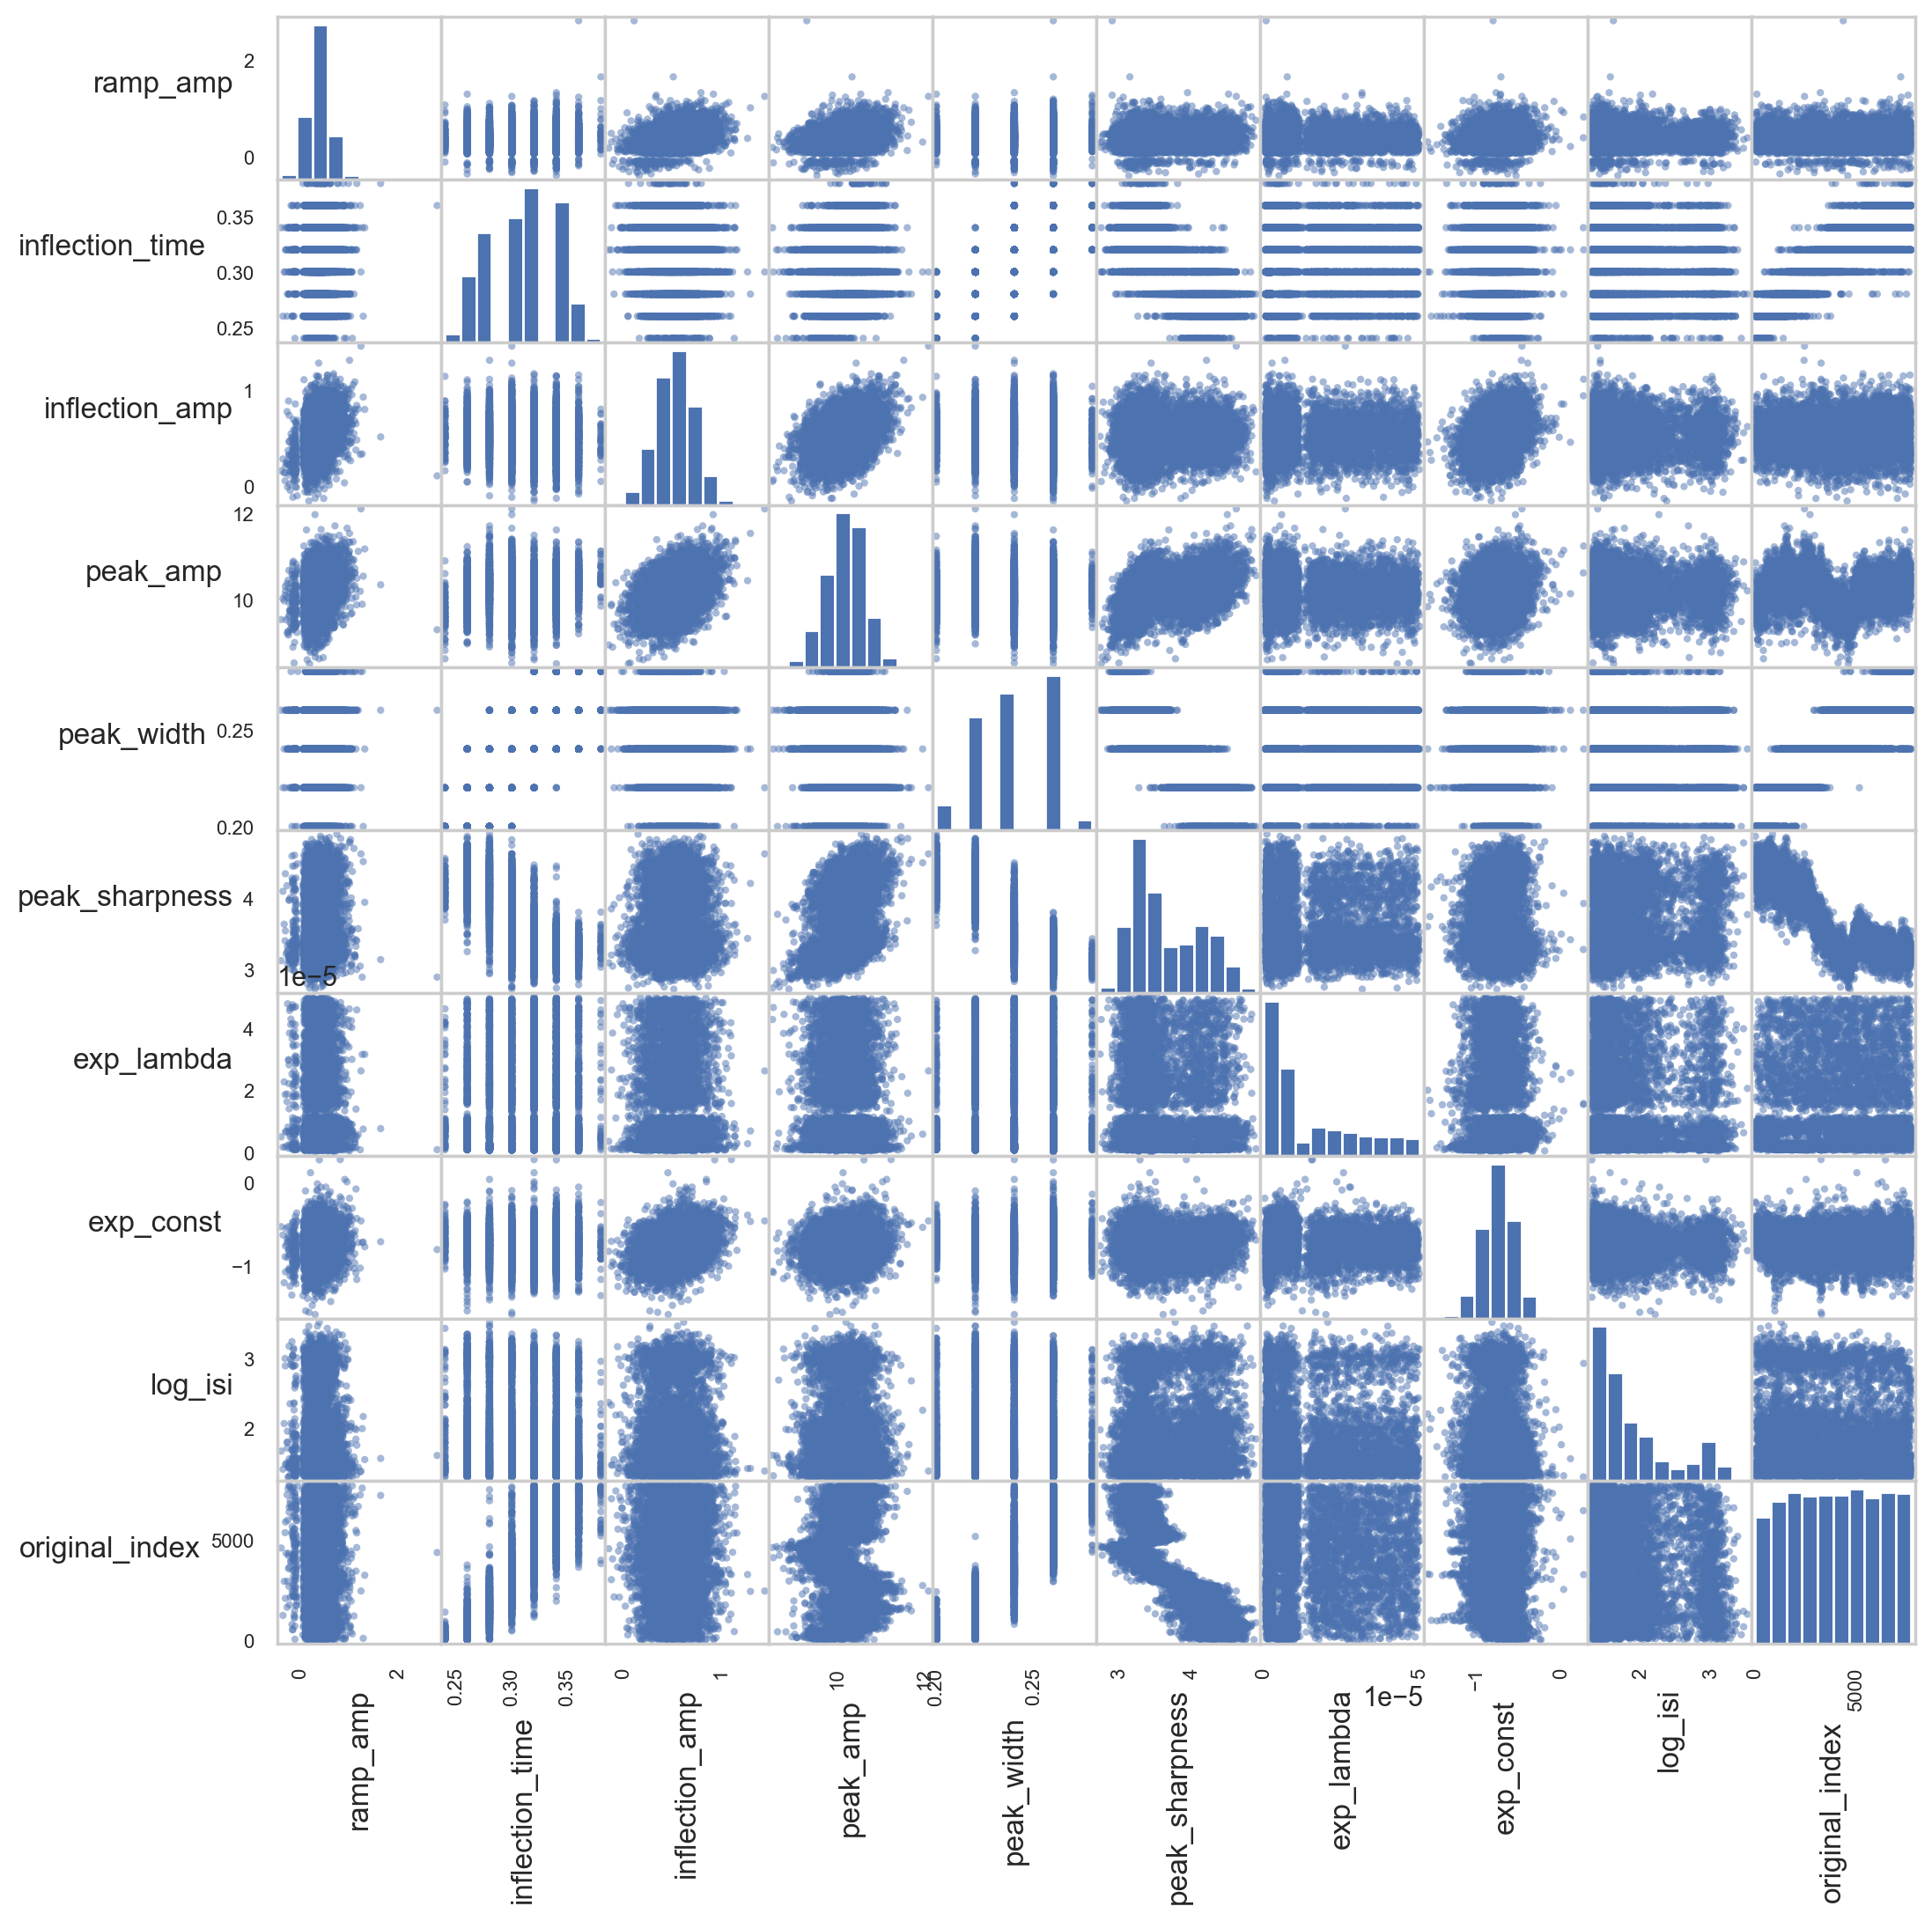

In [34]:
# Ensure inflection times are between 0 and 2 ms
df_features  = df_features .loc[df_features['inflection_time'] > 0]
df_features = df_features .loc[df_features['inflection_time'] < 2.]
#Filter based on inflection amplitude to remove weird sikes
#df_features  = df_features .loc[df_features['inflection_amp'] < 10]

# Remove low r-squares (ramping fits are especially noisy)
df_features = df_features.loc[df_features['r_squared_exp']  >= .5]
df_features = df_features.loc[df_features['r_squared_ramp'] >= .1]
# log10 ISIs
df_features[['isi']] = np.log10(df_features[['isi']])
df_features.rename(columns={'isi':'log_isi'}, inplace=True)
# drop no-longer-used QC features
df_features = df_features.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_features = df_features.replace([np.inf, -np.inf], np.nan)
# Drop rows where 'log_isi' is NaN
df_features = df_features.dropna(subset=['log_isi'])

axes = pd.plotting.scatter_matrix(df_features, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.show()

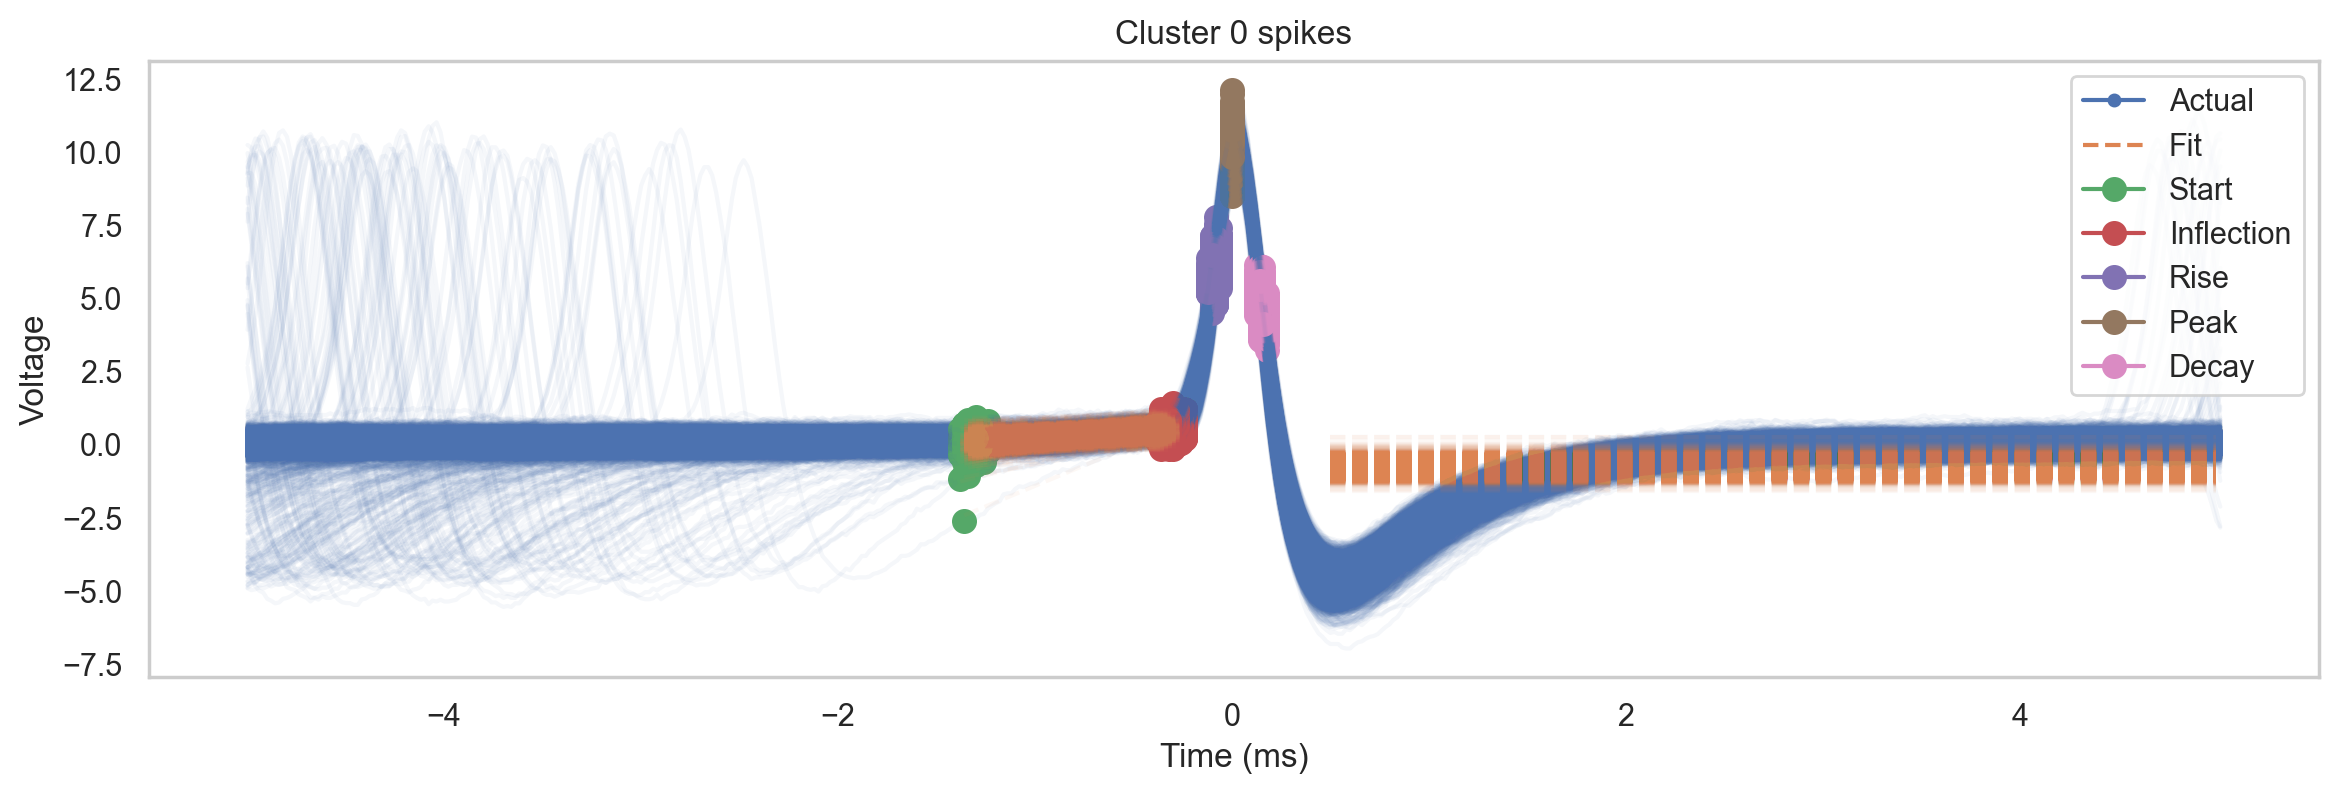

In [35]:
filtered_indices = df_features['original_index'].values
sp.plot(inds=filtered_indices, mode='full', show_points=True)
plt.title("Cluster 0 spikes")
plt.show()

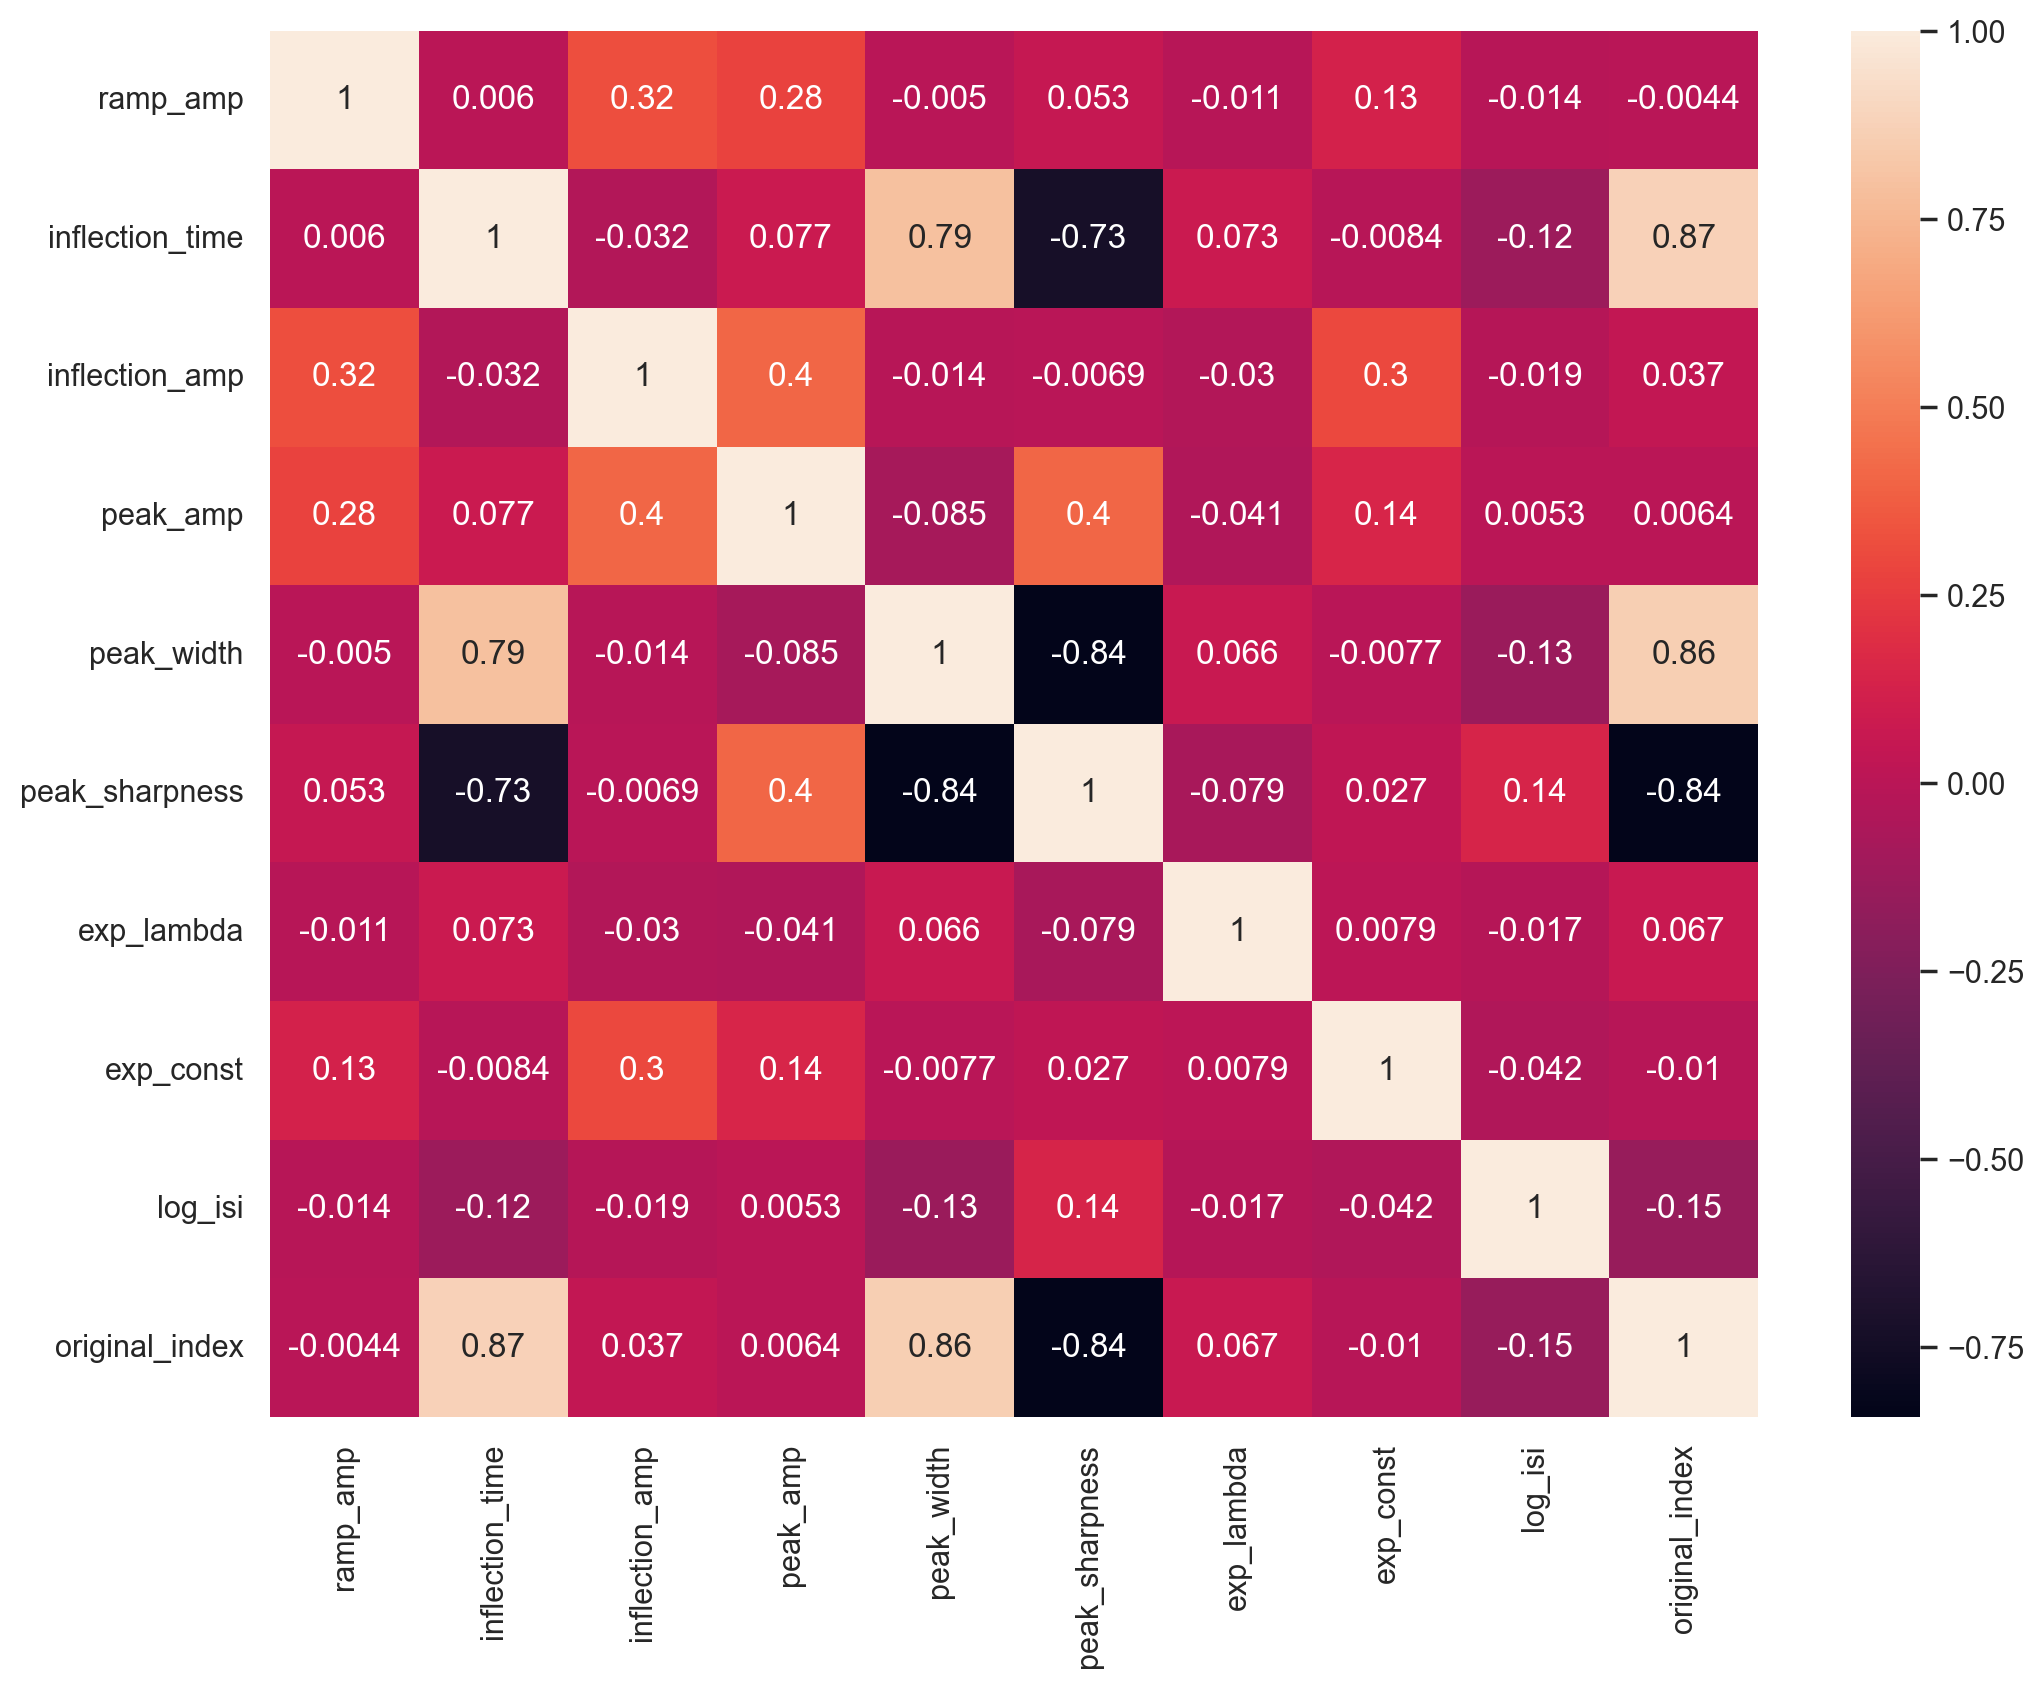

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,original_index
ramp_amp,1.0***,0.01,0.32***,0.28***,-0.01,0.05***,-0.01,0.13***,-0.01,-0.0
inflection_time,0.01,1.0***,-0.03**,0.08***,0.79***,-0.73***,0.07***,-0.01,-0.12***,0.87***
inflection_amp,0.32***,-0.03**,1.0***,0.4***,-0.01,-0.01,-0.03*,0.3***,-0.02,0.04**
peak_amp,0.28***,0.08***,0.4***,1.0***,-0.09***,0.4***,-0.04***,0.14***,0.01,0.01
peak_width,-0.01,0.79***,-0.01,-0.09***,1.0***,-0.84***,0.07***,-0.01,-0.13***,0.86***
peak_sharpness,0.05***,-0.73***,-0.01,0.4***,-0.84***,1.0***,-0.08***,0.03*,0.14***,-0.84***
exp_lambda,-0.01,0.07***,-0.03*,-0.04***,0.07***,-0.08***,1.0***,0.01,-0.02,0.07***
exp_const,0.13***,-0.01,0.3***,0.14***,-0.01,0.03*,0.01,1.0***,-0.04***,-0.01
log_isi,-0.01,-0.12***,-0.02,0.01,-0.13***,0.14***,-0.02,-0.04***,1.0***,-0.15***
original_index,-0.0,0.87***,0.04**,0.01,0.86***,-0.84***,0.07***,-0.01,-0.15***,1.0***


In [36]:
#df_features_correlation = df_features.corr()
# Plot the heatmap and annotation on it
sns.heatmap(df_features.corr(), xticklabels=df_features.corr().columns,
            yticklabels=df_features.corr().columns, annot=True)
plt.show()
rho = df_features.corr()
pval = df_features.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

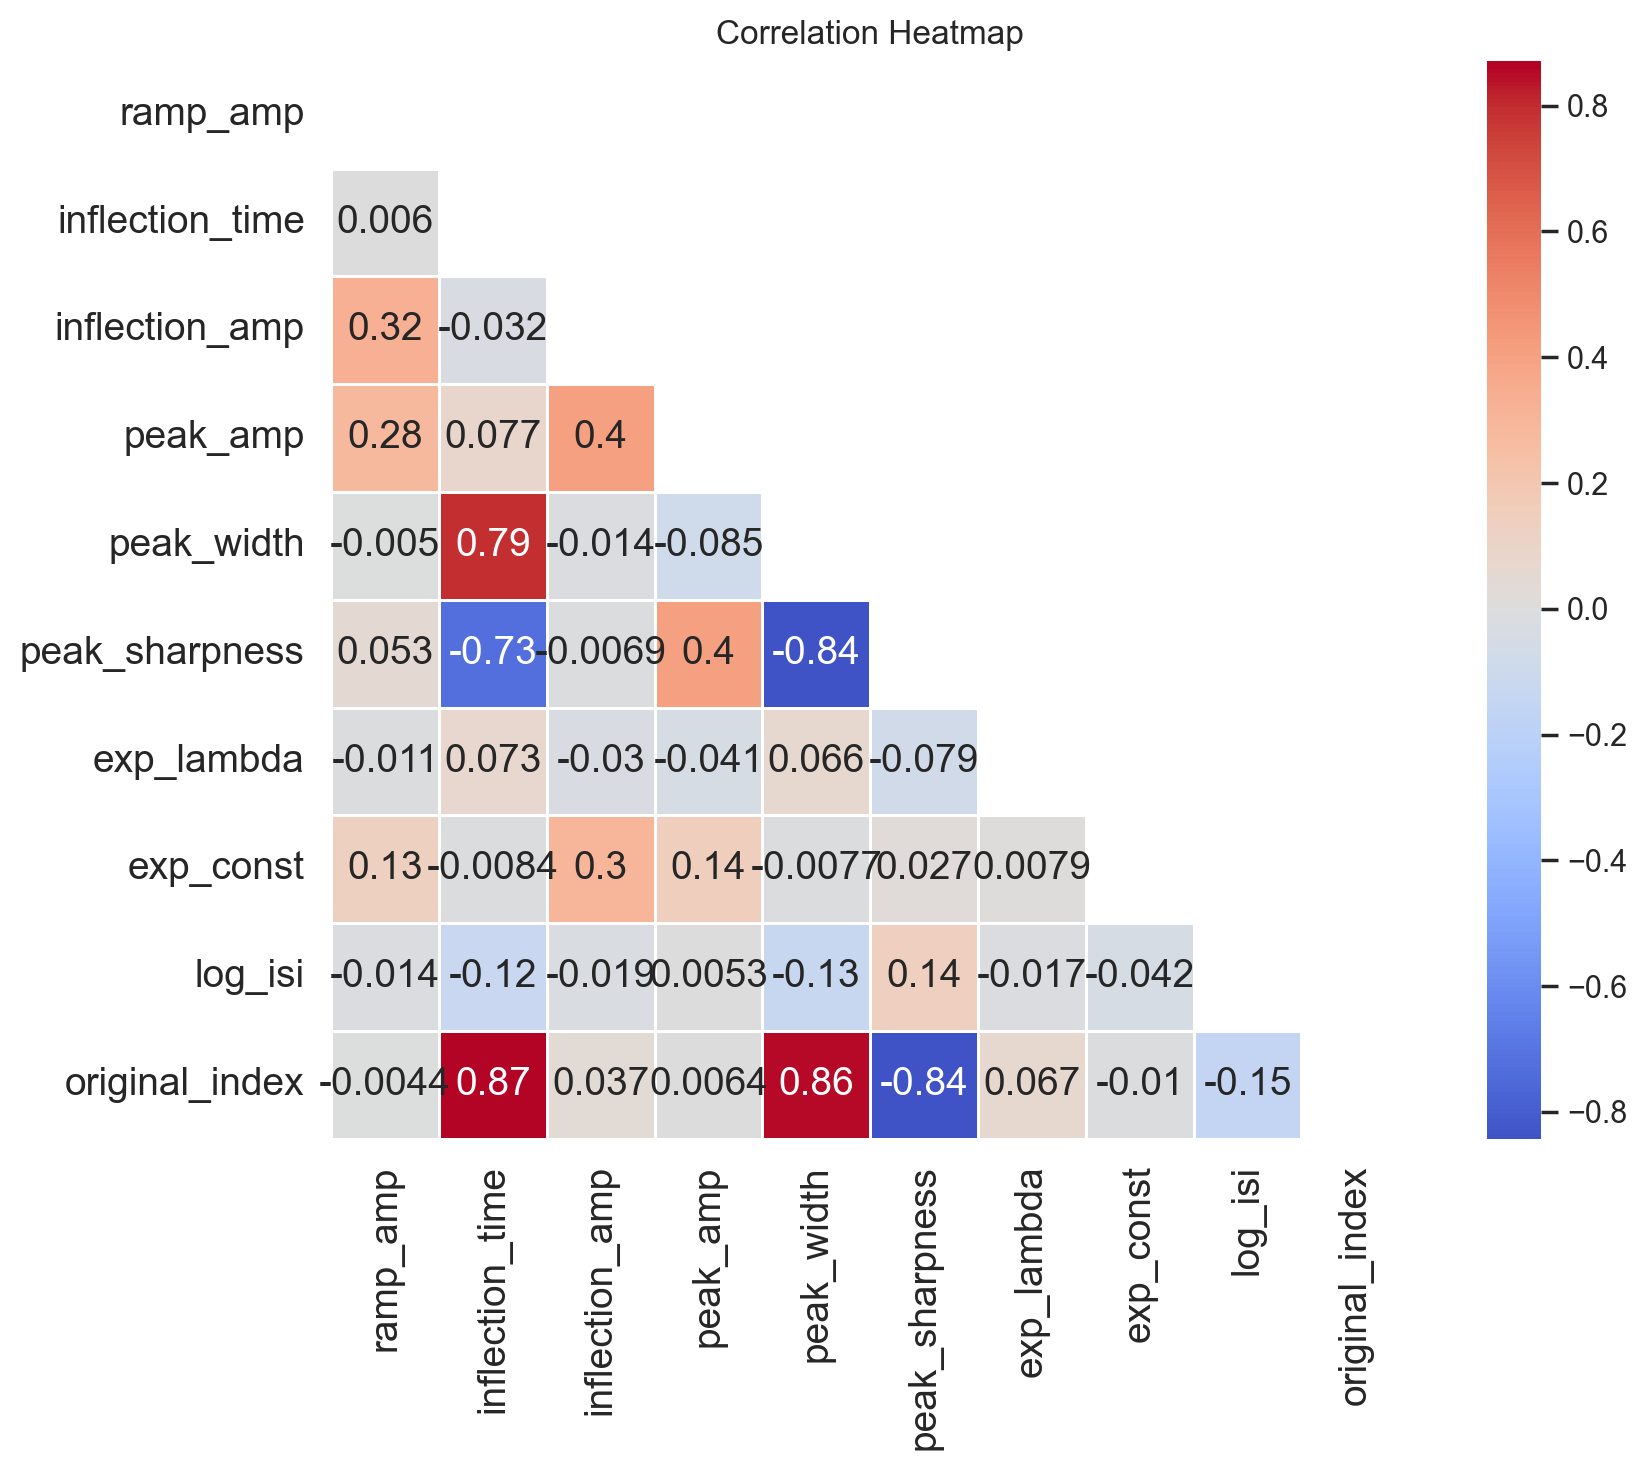

In [37]:
# Calculate correlation matrix and p-values
rho = df_features.corr()
pval = df_features.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval < 0.05  # Create a mask for significant p-values

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(rho, dtype=bool))

# Plot the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(rho, mask=mask, cmap='coolwarm', annot=True, fmt='.2', linewidths=0.5, center=0, square=True,  annot_kws={"size": 14})
# Increase fontsize of tick labels on both axes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.title('Correlation Heatmap')
plt.show()


## Linear regression model to predict time of next spike (isi) based on inflection features 

(array([2135., 1499.,  821.,  624.,  279.,  171.,  252.,  549.,  209.,
          19.]),
 array([1.30082233, 1.52213318, 1.74344404, 1.96475489, 2.18606574,
        2.40737659, 2.62868744, 2.84999829, 3.07130914, 3.29261999,
        3.51393084]),
 <BarContainer object of 10 artists>)

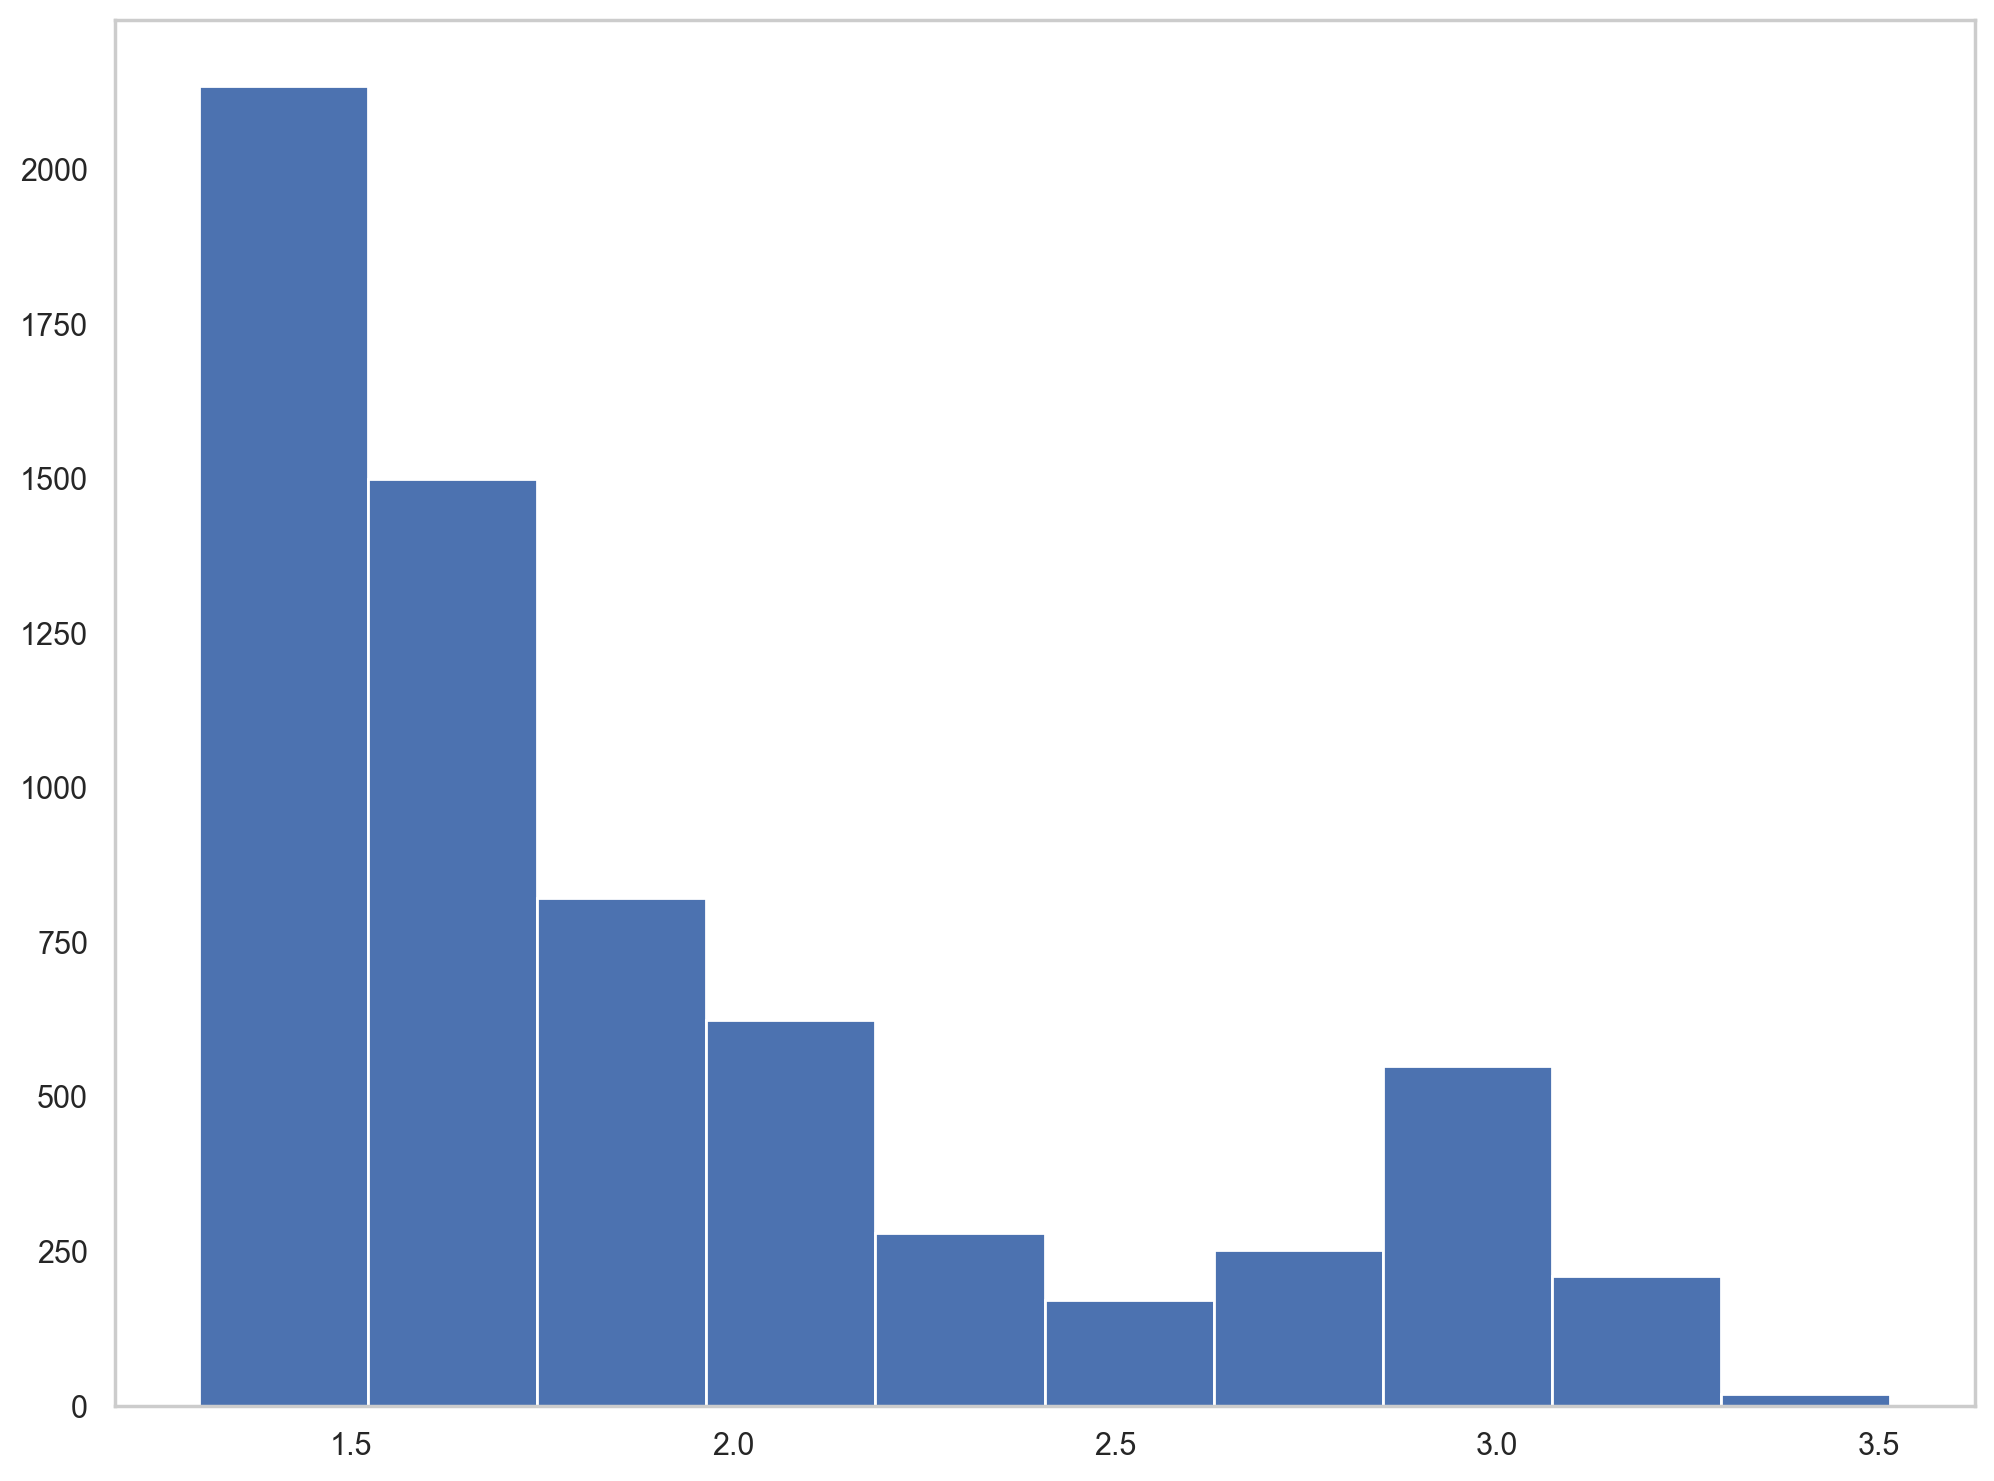

In [40]:
plt.hist(df_features['log_isi'])



Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


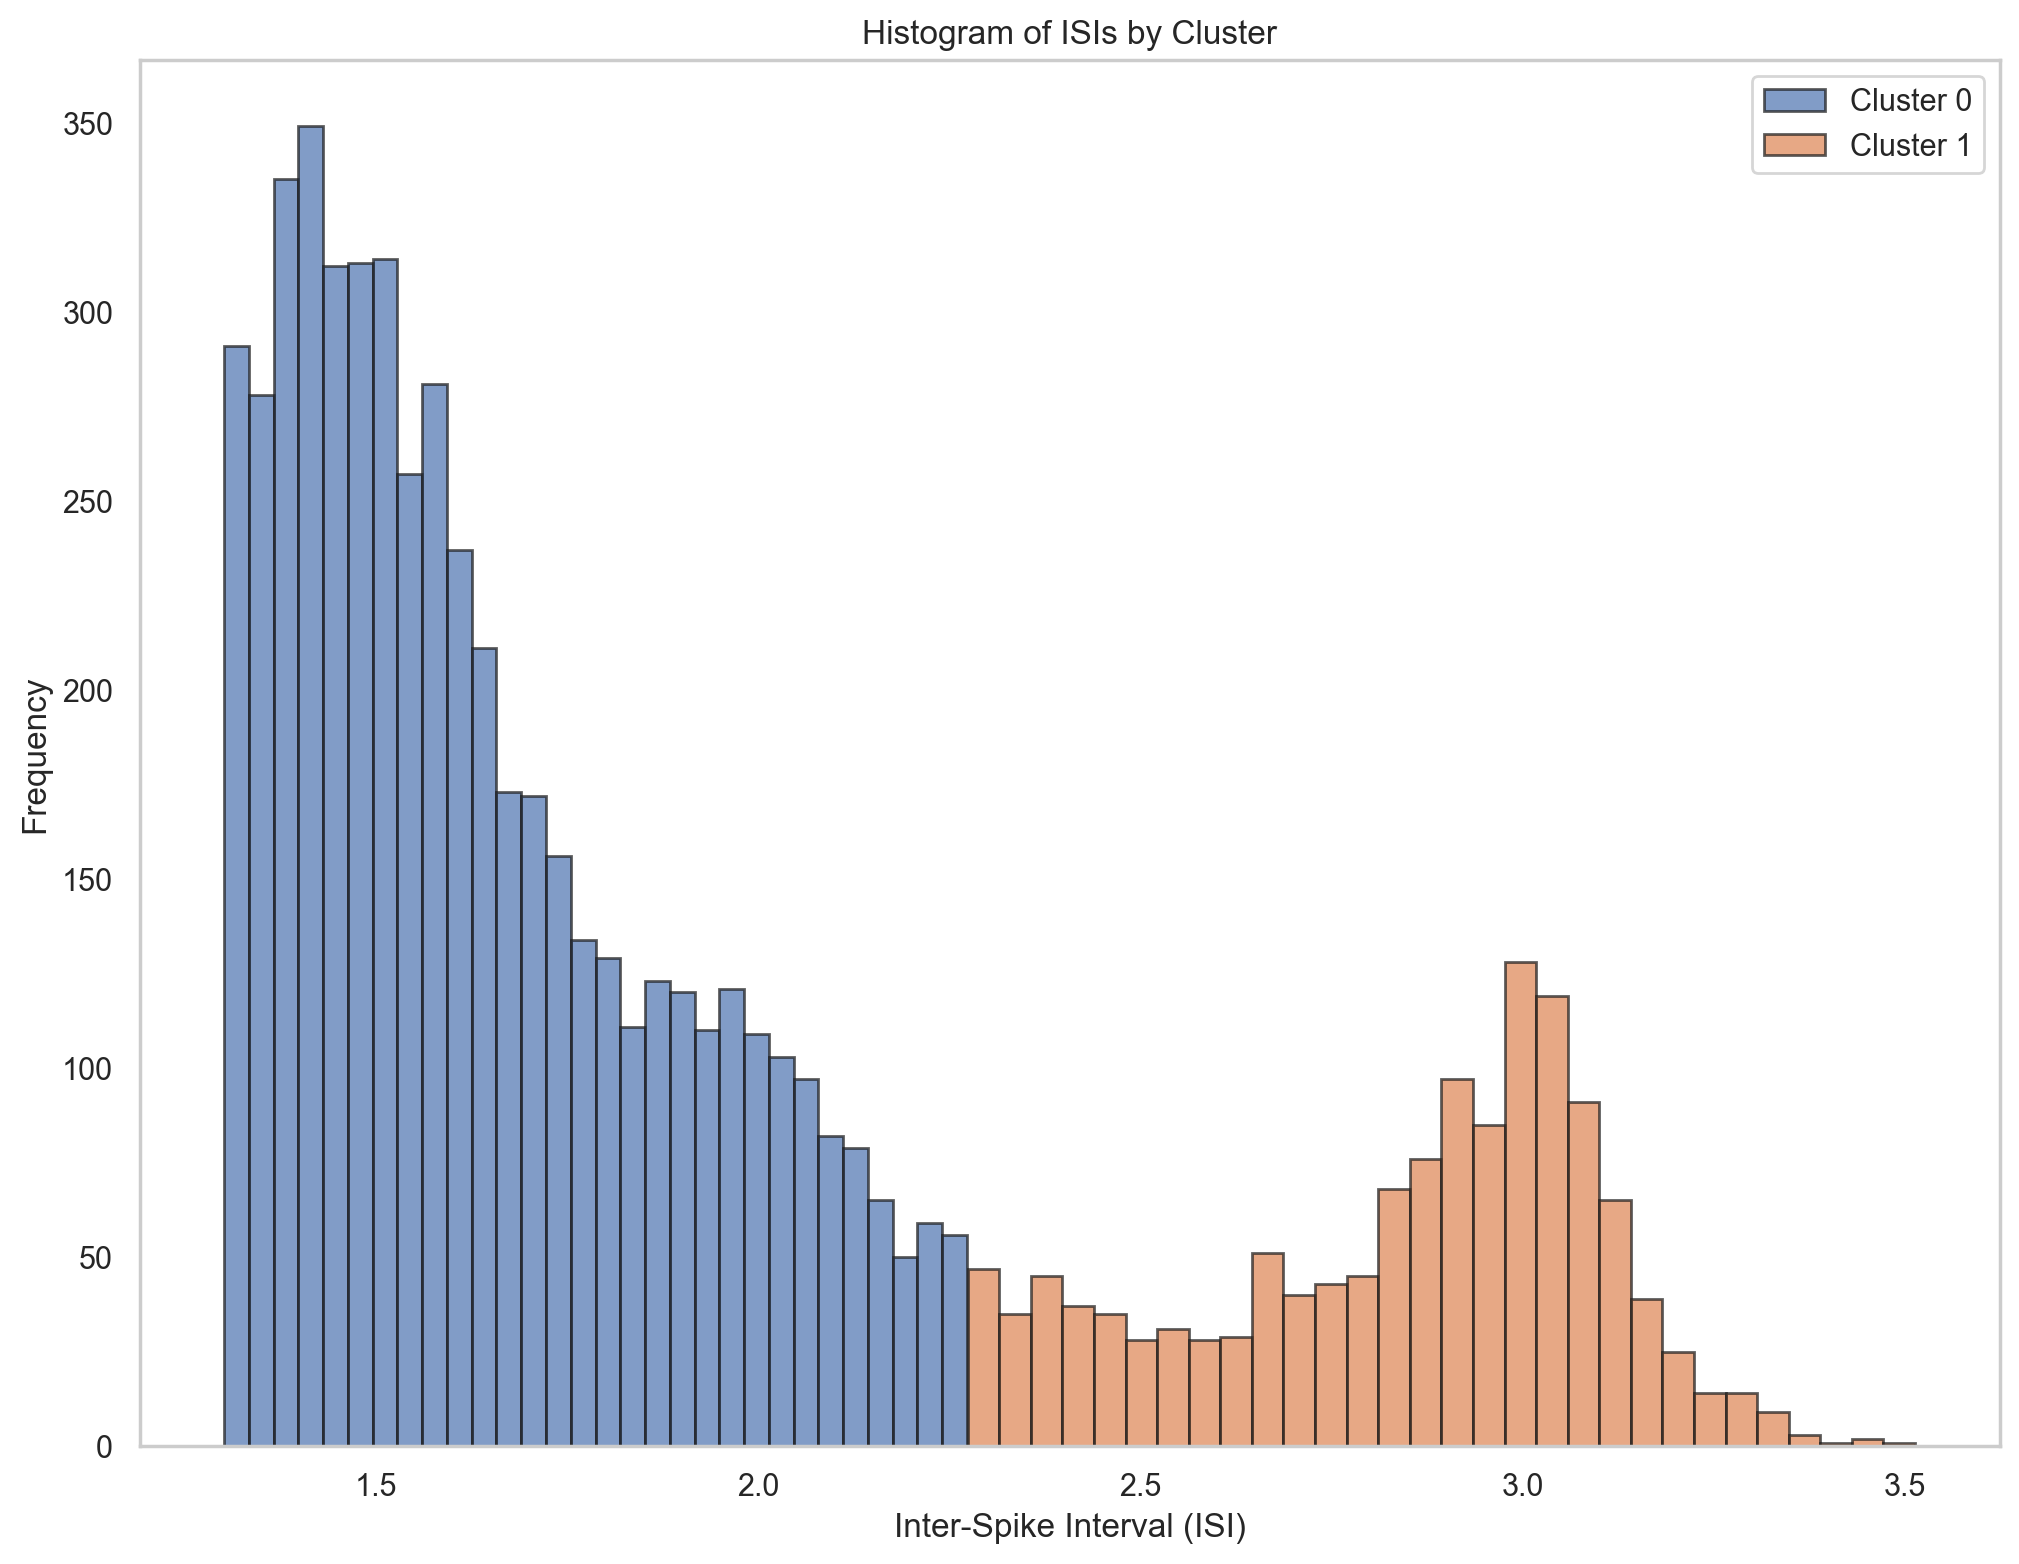

In [41]:
#split two clusters and then generate two different models?
isis = df_features['log_isi'].values
isis_reshaped = isis.reshape(-1, 1) 

# Perform MiniBatchKMeans clustering
mini_kmeans = MiniBatchKMeans(n_clusters=2, random_state=0, batch_size=100).fit(isis_reshaped)
clusters = mini_kmeans.labels_

# Visualize the clusters
plt.hist(isis[clusters == 0], bins=30, edgecolor='k', alpha=0.7, label='Cluster 0')
plt.hist(isis[clusters == 1], bins=30, edgecolor='k', alpha=0.7, label='Cluster 1')
plt.xlabel('Inter-Spike Interval (ISI)')
plt.ylabel('Frequency')
plt.title('Histogram of ISIs by Cluster')
plt.legend()
plt.show()

In [42]:
#separate features and target

features = df_features.drop(columns=['log_isi']).values
target = df_features['log_isi'].values

# Split features and target based on clusters
features_cluster_0 = features[clusters == 0]
target_cluster_0 = target[clusters == 0]
features_cluster_1 = features[clusters == 1]
target_cluster_1 = target[clusters == 1]

original_indices = df_features['original_index'].values
original_indices_cluster_0 = original_indices[clusters == 0]
original_indices_cluster_1 = original_indices[clusters == 1]

In [ ]:
# Plot spikes for Cluster 0
sp.plot(inds=original_indices_cluster_0, mode='full', show_points=True)
plt.title("Cluster 0 spikes")
plt.ylim(-100,100)
plt.show()


# Plot spikes for Cluster 1
sp.plot(inds=original_indices_cluster_1, mode='full', show_points=True)
plt.title("Cluster 1 spikes")
plt.ylim(-100,100)
plt.show()

In [44]:
# Standardize features
scaler_0 = StandardScaler()
features_cluster_0_scaled = scaler_0.fit_transform(features_cluster_0)

scaler_1 = StandardScaler()
features_cluster_1_scaled = scaler_1.fit_transform(features_cluster_1)

# Split data into training and test sets
X_train_0, X_test_0, y_train_0, y_test_0 = train_test_split(features_cluster_0_scaled, target_cluster_0, test_size=0.2, random_state=42)
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(features_cluster_1_scaled, target_cluster_1, test_size=0.2, random_state=42)

# Function to train the model with progress tracking
def train_model_with_progress(X_train, y_train, max_iter=1000):
    model = Ridge(solver='saga', max_iter=1, random_state=42)
    progress_bar = tqdm(range(max_iter), desc="Training Ridge Regression")
    for _ in progress_bar:
        model.max_iter += 1
        model.fit(X_train, y_train)
    return model

# Train models with progress tracking
start_time = time.time()
model_0 = train_model_with_progress(X_train_0, y_train_0)
print("Training time for model_0:", time.time() - start_time)

start_time = time.time()
model_1 = train_model_with_progress(X_train_1, y_train_1)
print("Training time for model_1:", time.time() - start_time)

# Predict and calculate mean squared error
predictions_0 = model_0.predict(X_test_0)
mse_0 = mean_squared_error(y_test_0, predictions_0)
print(f'Mean Squared Error for Cluster 0: {mse_0}')

predictions_1 = model_1.predict(X_test_1)
mse_1 = mean_squared_error(y_test_1, predictions_1)
print(f'Mean Squared Error for Cluster 1: {mse_1}')


Training Ridge Regression:   0%|          | 0/1000 [00:00<?, ?it/s]

Training time for model_0: 6.060135841369629


Training Ridge Regression:   0%|          | 0/1000 [00:00<?, ?it/s]

Training time for model_1: 2.1532399654388428
Mean Squared Error for Cluster 0: 0.0610958544453952
Mean Squared Error for Cluster 1: 0.06793950914725094


In [45]:
#rsq values
r2_0 = r2_score(y_test_0, predictions_0)
r2_1 = r2_score(y_test_1, predictions_1)

print(f'R-squared for Cluster 0: {r2_0}')

print(f'R-squared for Cluster 1: {r2_1}')

R-squared for Cluster 0: 0.023521436038352994
R-squared for Cluster 1: -4.3839038175175205e-06


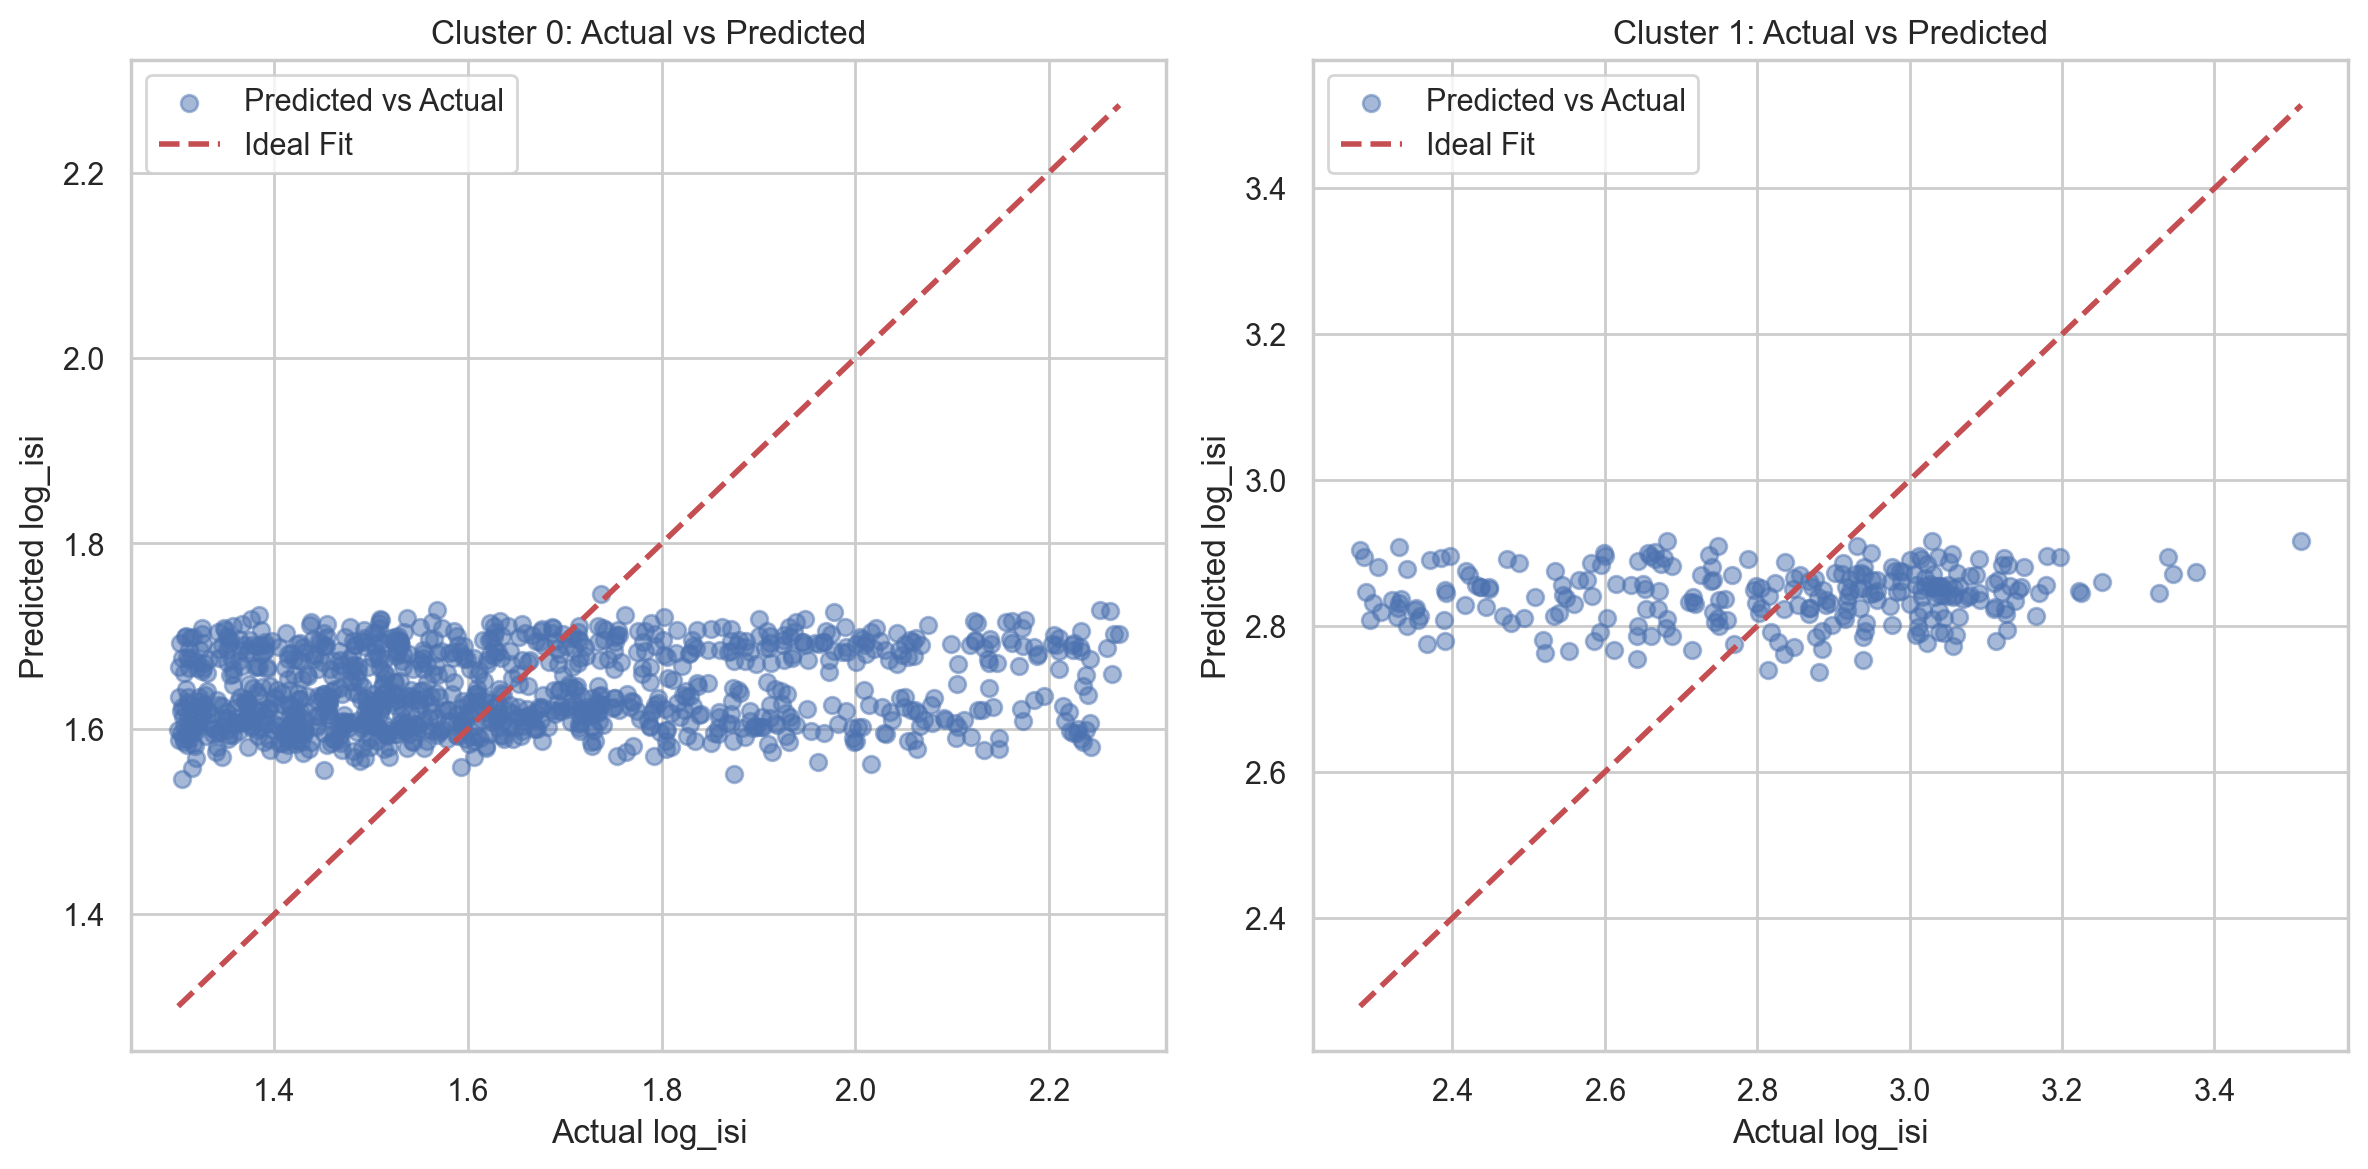

In [46]:
# Visualize the results

# Plotting actual vs predicted values for Cluster 0
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test_0, predictions_0, alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test_0.min(), y_test_0.max()], [y_test_0.min(), y_test_0.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual log_isi')
plt.ylabel('Predicted log_isi')
plt.title('Cluster 0: Actual vs Predicted')
plt.legend()
plt.grid(True)

# Plotting actual vs predicted values for Cluster 1
plt.subplot(1, 2, 2)
plt.scatter(y_test_1, predictions_1, alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test_1.min(), y_test_1.max()], [y_test_1.min(), y_test_1.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual log_isi')
plt.ylabel('Predicted log_isi')
plt.title('Cluster 1: Actual vs Predicted')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

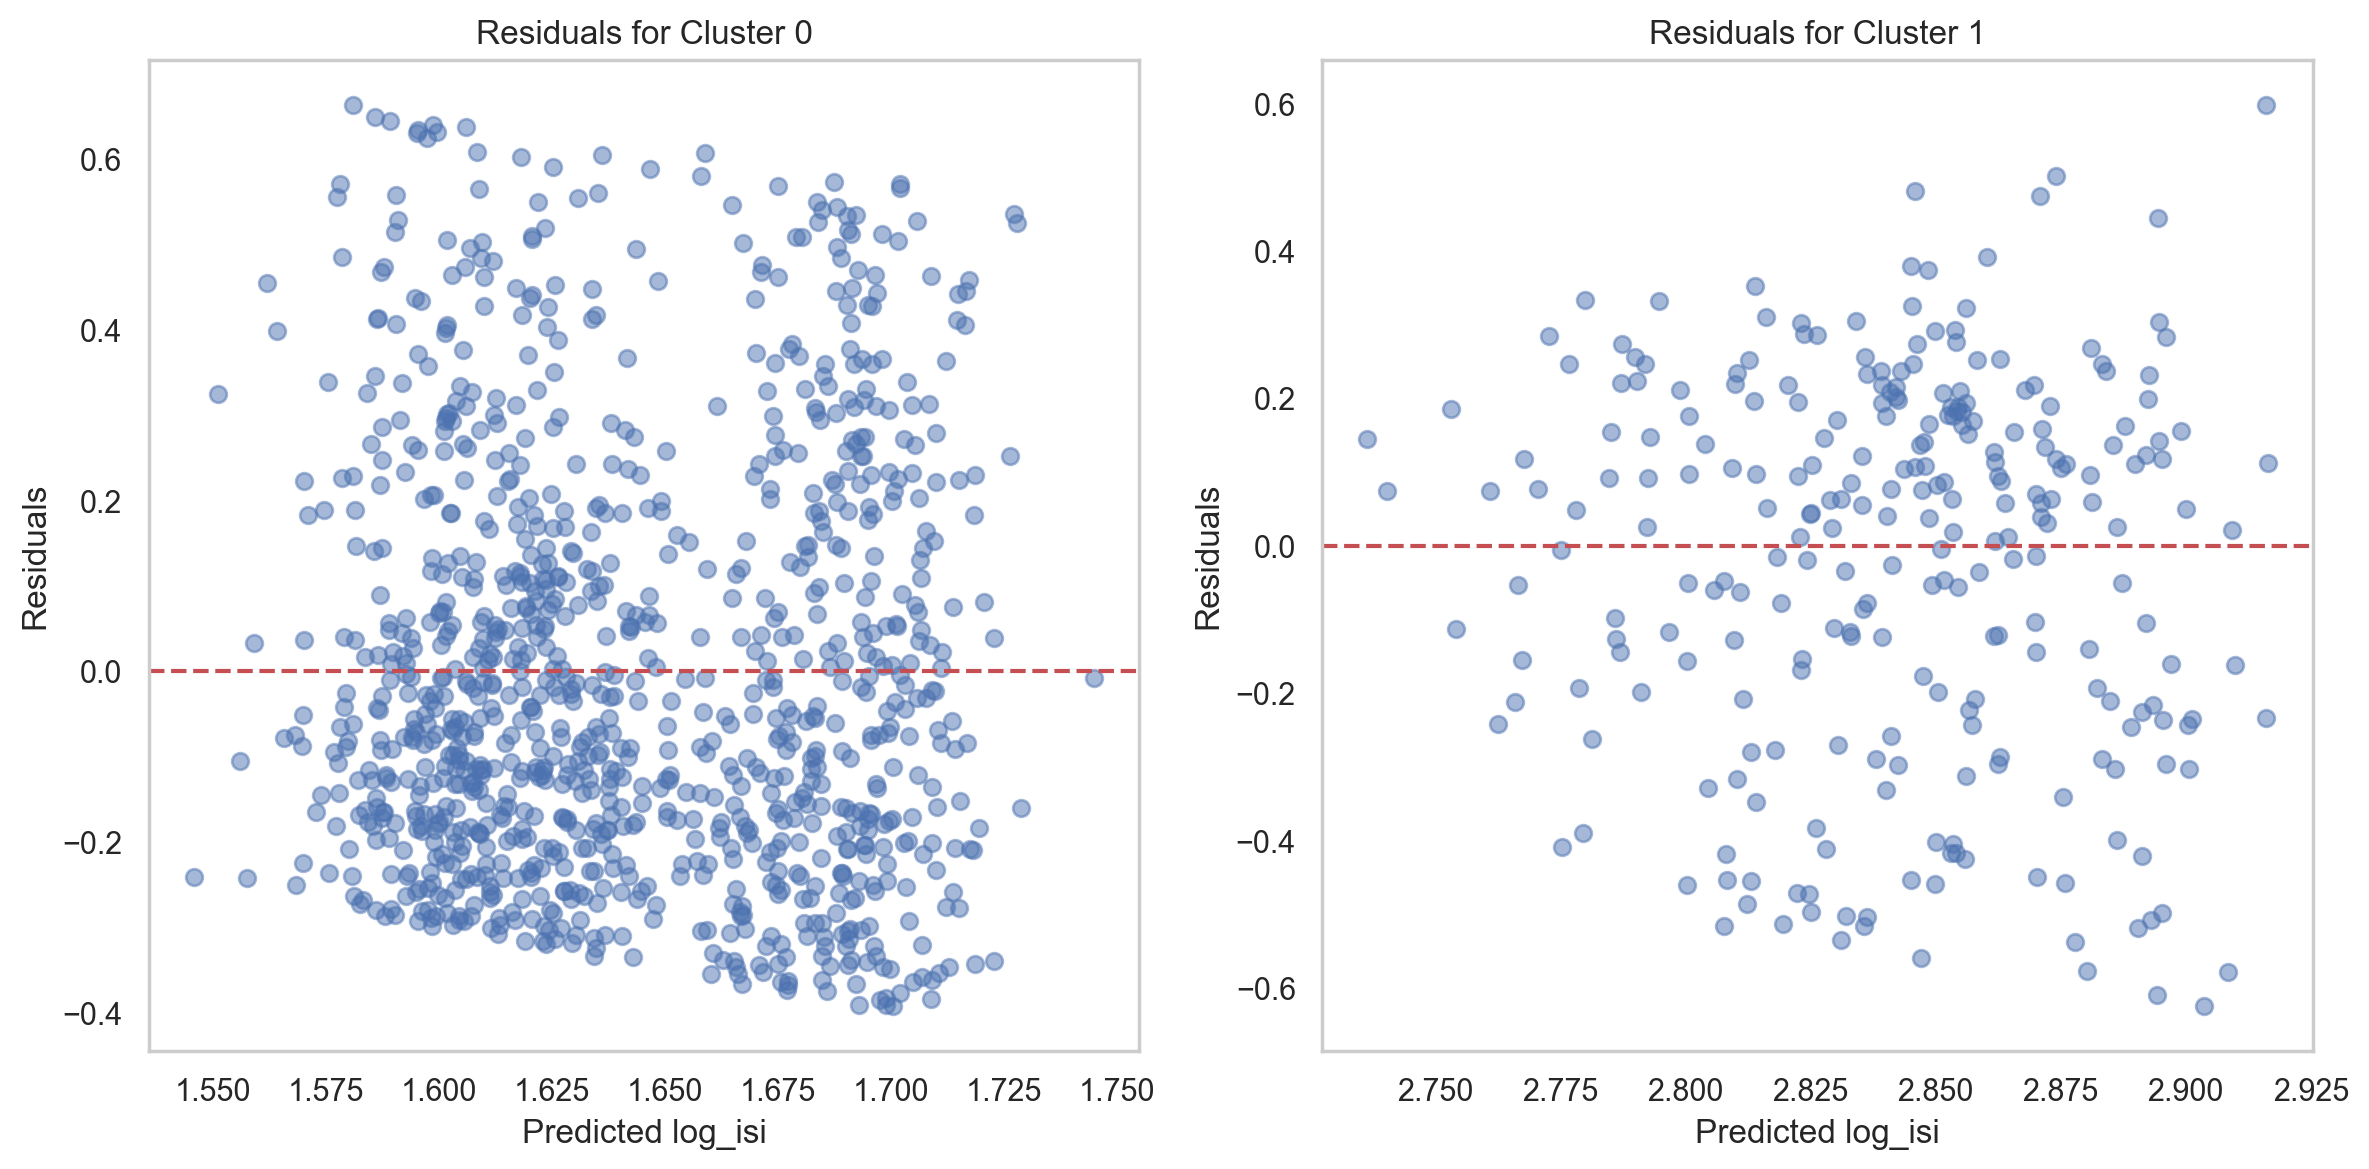

In [47]:
# Calculate residuals
residuals_0 = y_test_0 - predictions_0
residuals_1 = y_test_1 - predictions_1

# Plot residuals for Cluster 0
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(predictions_0, residuals_0, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted log_isi')
plt.ylabel('Residuals')
plt.title('Residuals for Cluster 0')

# Plot residuals for Cluster 1
plt.subplot(1, 2, 2)
plt.scatter(predictions_1, residuals_1, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted log_isi')
plt.ylabel('Residuals')
plt.title('Residuals for Cluster 1')

plt.tight_layout()
plt.show()

In [48]:
### Feature importance

num_features_0 = features_cluster_0.shape[1]
num_features_1 = features_cluster_1.shape[1]

features_0 = [f'Feature_{i}' for i in range(num_features_0)]
features_1 = [f'Feature_{i}' for i in range(num_features_1)]

# Extract coefficients from the trained models
coefficients_0 = model_0.coef_
coefficients_1 = model_1.coef_

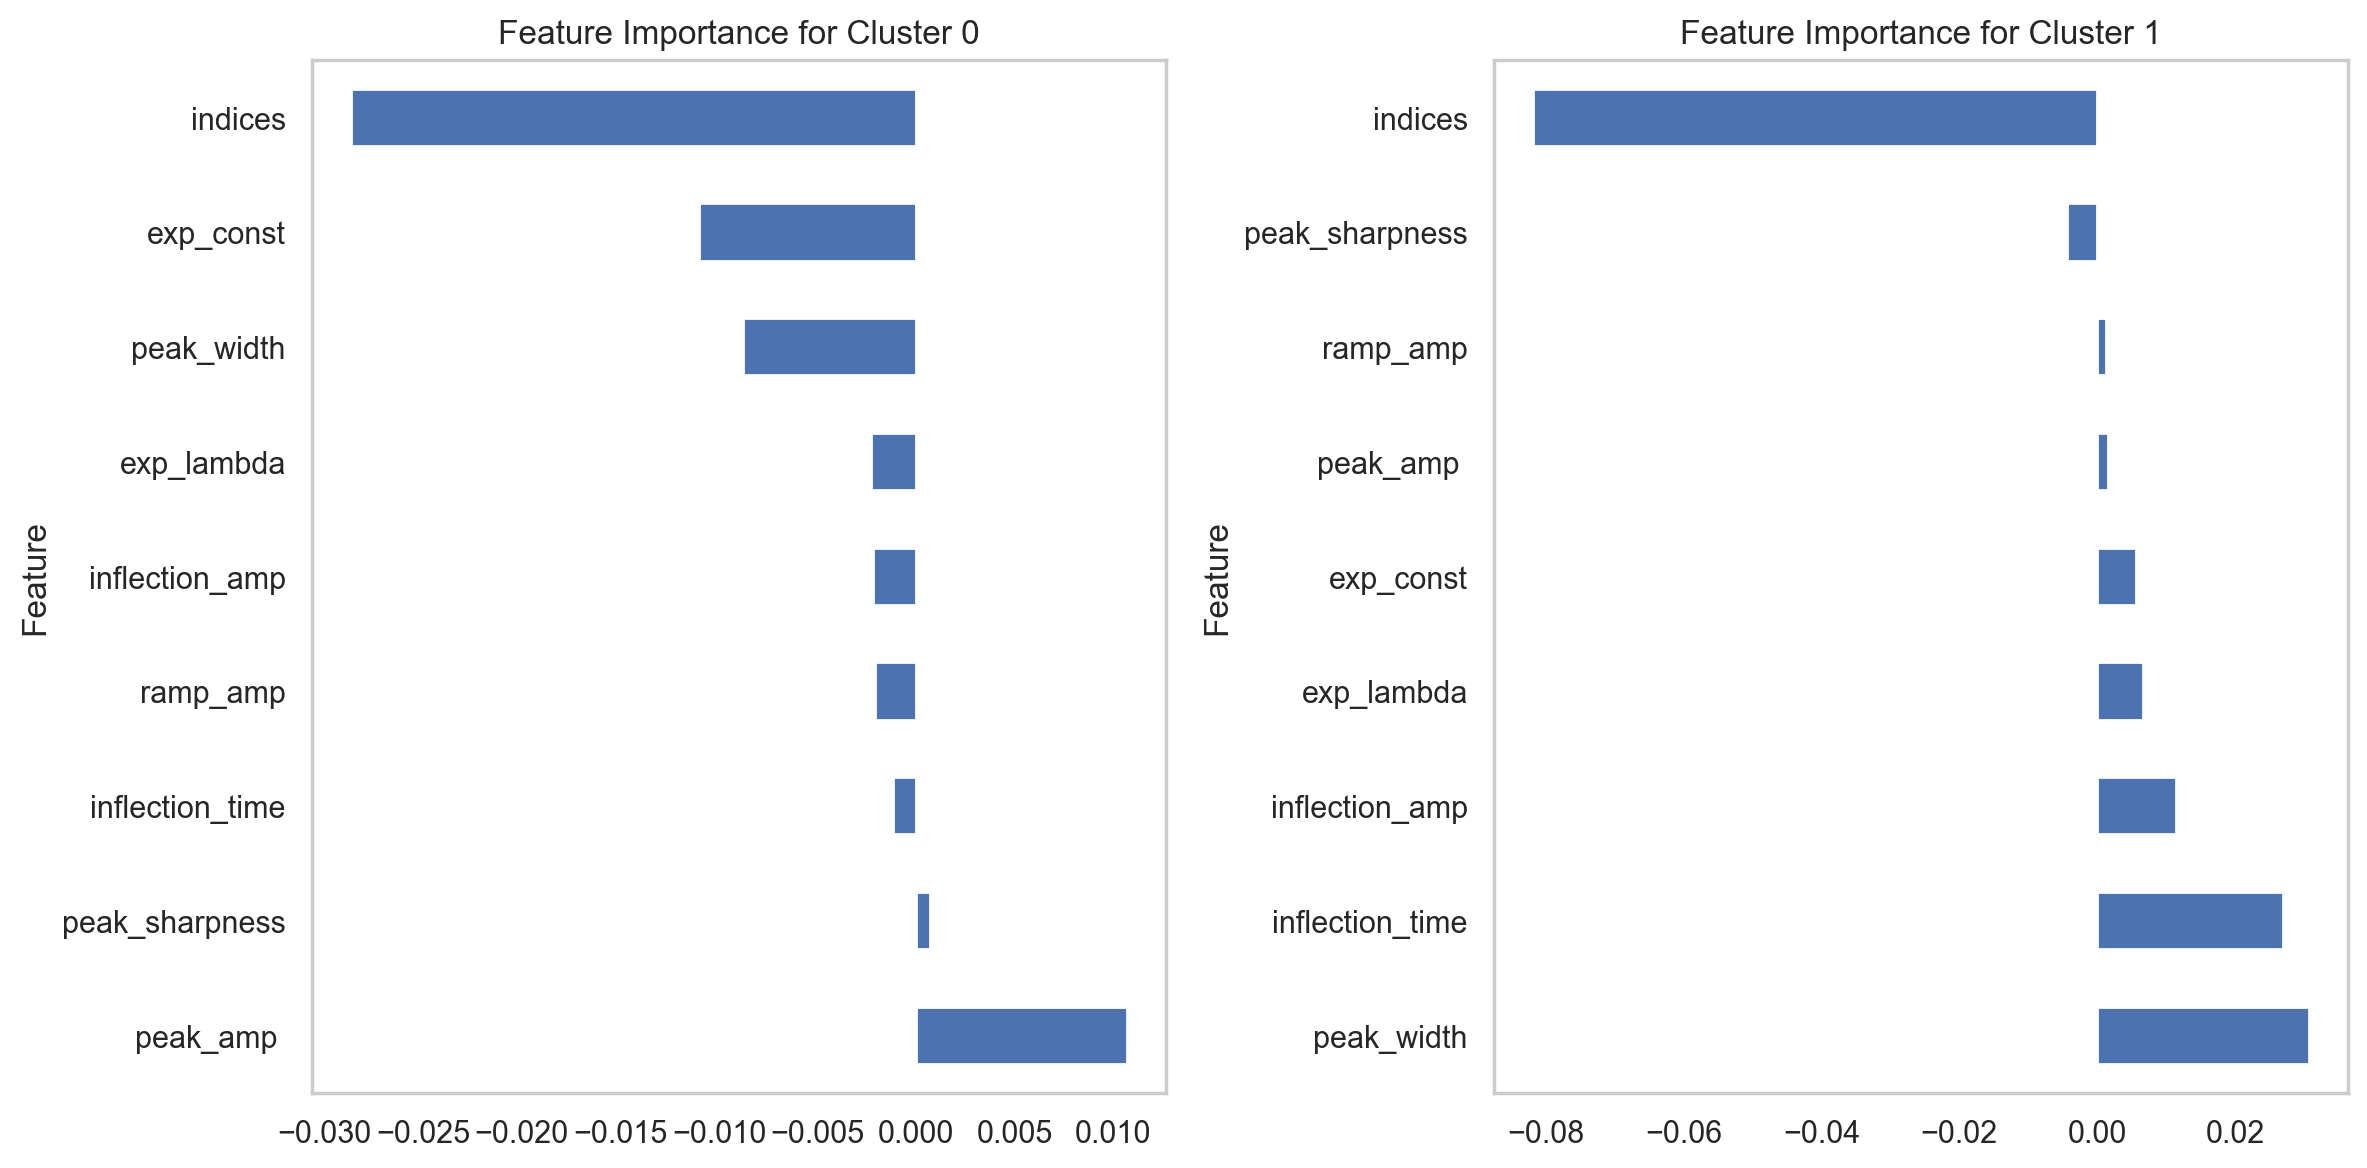

In [49]:
# Assuming you have the actual feature names
actual_feature_names = ['ramp_amp', 'inflection_time', 	'inflection_amp', 	'peak_amp ',	'peak_width', 	'peak_sharpness', 	'exp_lambda', 	'exp_const', 'indices']  # replace with your actual feature names


# Create DataFrames for feature importance
feature_importance_0 = pd.DataFrame({
    'Feature': actual_feature_names,
    'Importance': coefficients_0
})

feature_importance_1 = pd.DataFrame({
    'Feature': actual_feature_names,
    'Importance': coefficients_1
})

# Plot feature importance for Cluster 0
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
feature_importance_0.sort_values(by='Importance', ascending=False).plot.barh(x='Feature', y='Importance', ax=plt.gca(), legend=False)
plt.title('Feature Importance for Cluster 0')

# Plot feature importance for Cluster 1
plt.subplot(1, 2, 2)
feature_importance_1.sort_values(by='Importance', ascending=False).plot.barh(x='Feature', y='Importance', ax=plt.gca(), legend=False)
plt.title('Feature Importance for Cluster 1')

plt.tight_layout()
plt.show()


### Run regression without splitting into clusters 

In [50]:
# Standardize features
scaler = StandardScaler()
features = df_features.drop(columns=['log_isi']).values
target = df_features['log_isi'].values

features_scaled = scaler.fit_transform(features)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)


# Function to train the model with progress tracking
def train_model_with_progress(X_train, y_train, max_iter=1000):
    model = Ridge(solver='saga', max_iter=1, random_state=42)
    progress_bar = tqdm(range(max_iter), desc="Training Ridge Regression")
    for _ in progress_bar:
        model.max_iter += 1
        model.fit(X_train, y_train)
    return model

In [51]:
# Train model with progress tracking
start_time = time.time()
model = train_model_with_progress(X_train, y_train)
print("Training time for the model:", time.time() - start_time)

# Predict and calculate mean squared error and R-squared
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Training Ridge Regression:   0%|          | 0/1000 [00:00<?, ?it/s]

Training time for the model: 8.15920090675354
Mean Squared Error: 0.29815732262613615
R-squared: 0.020787683862704687


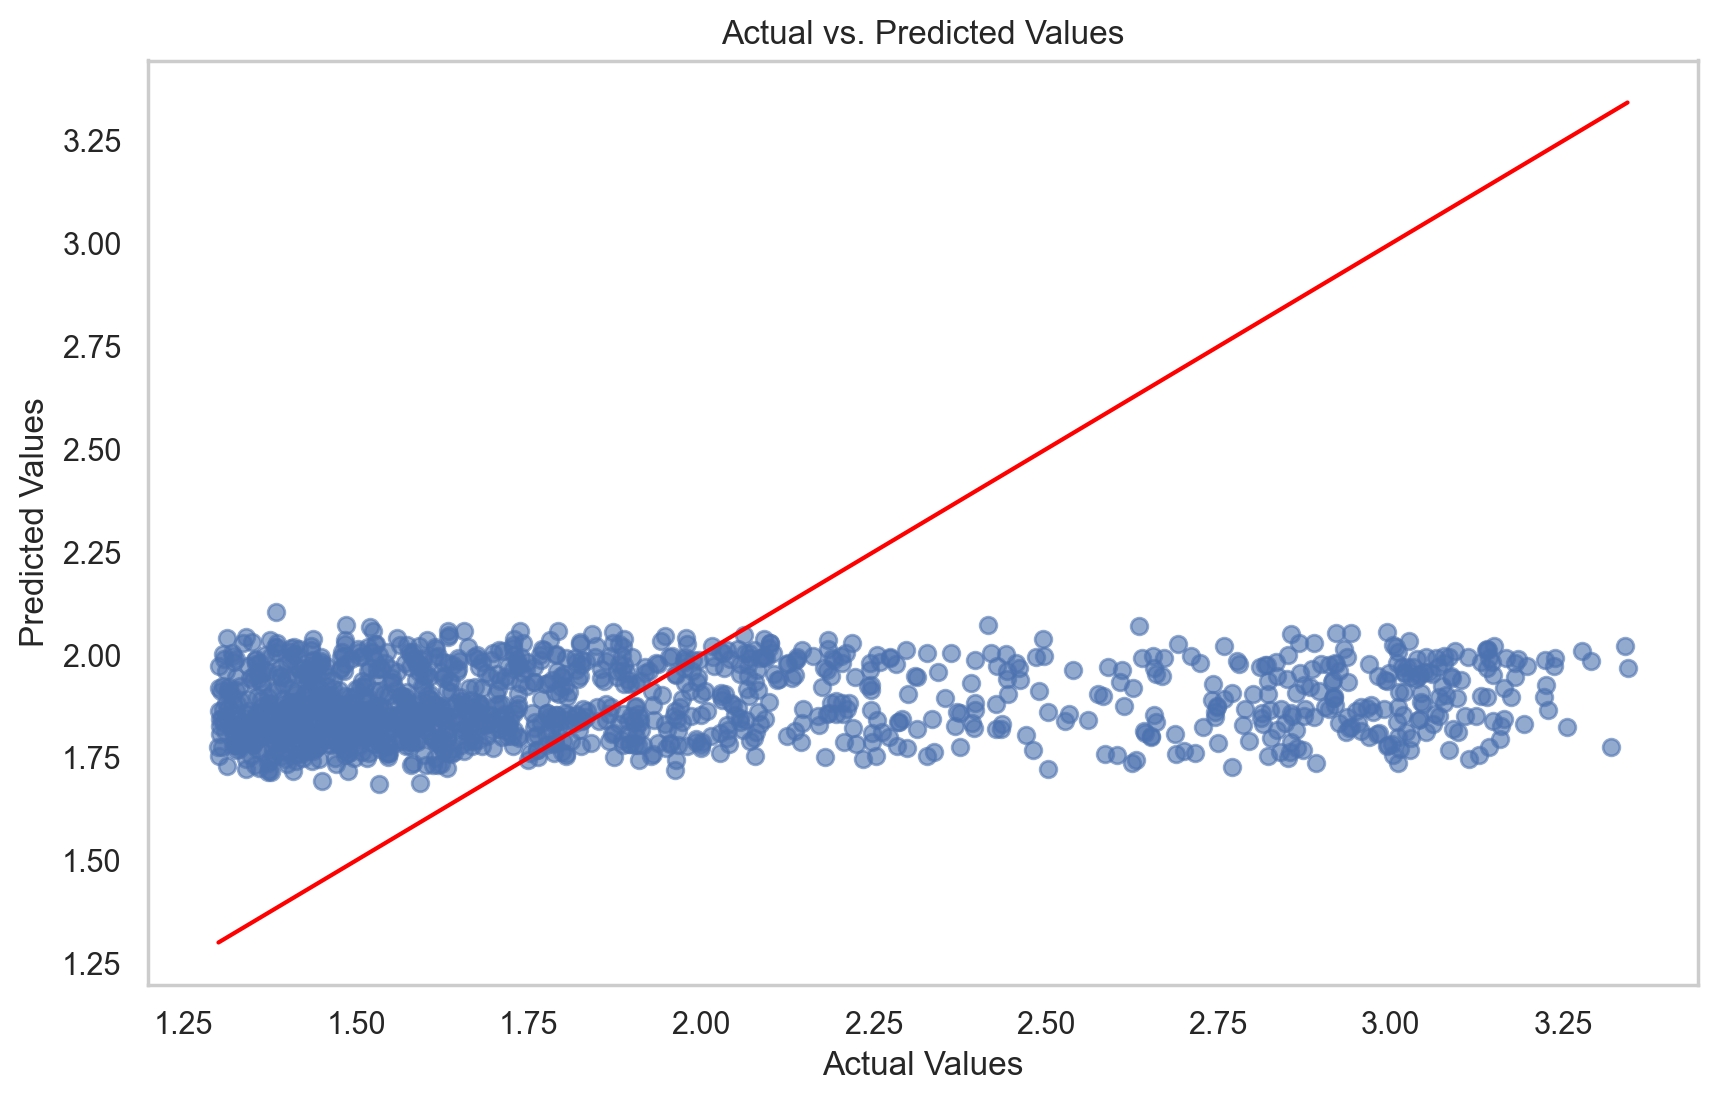

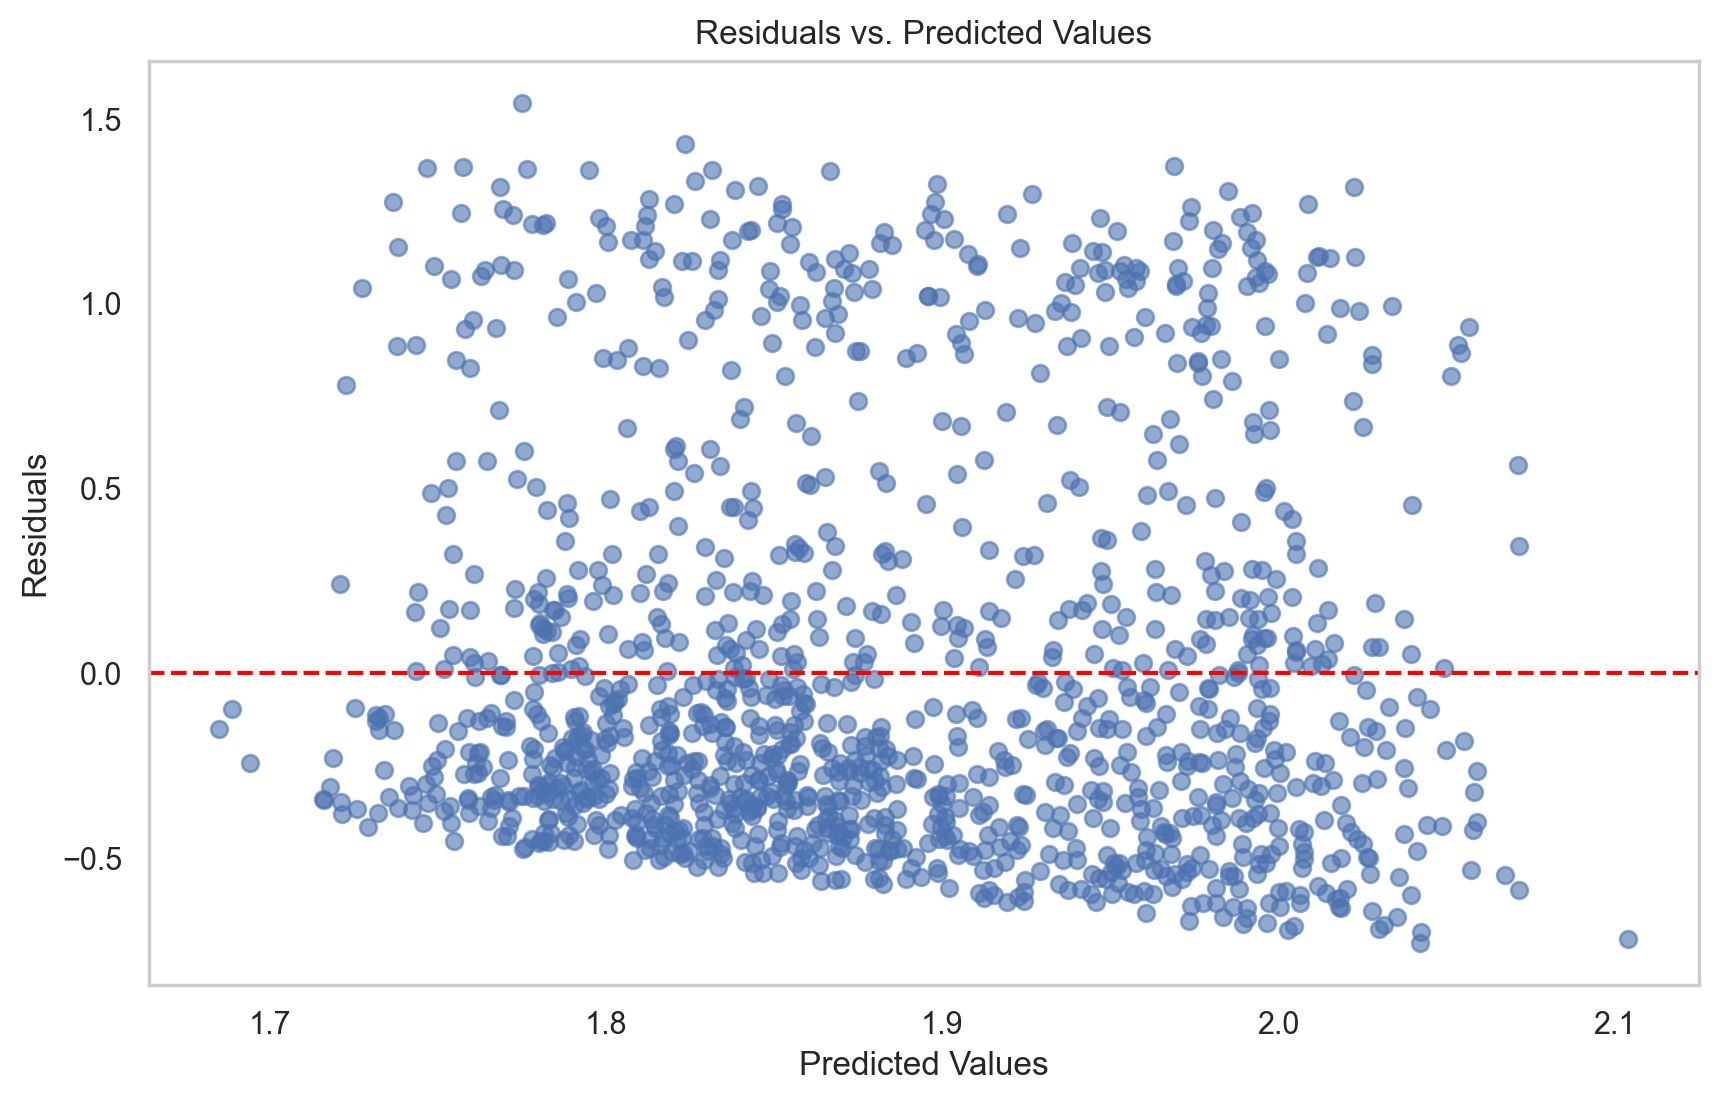

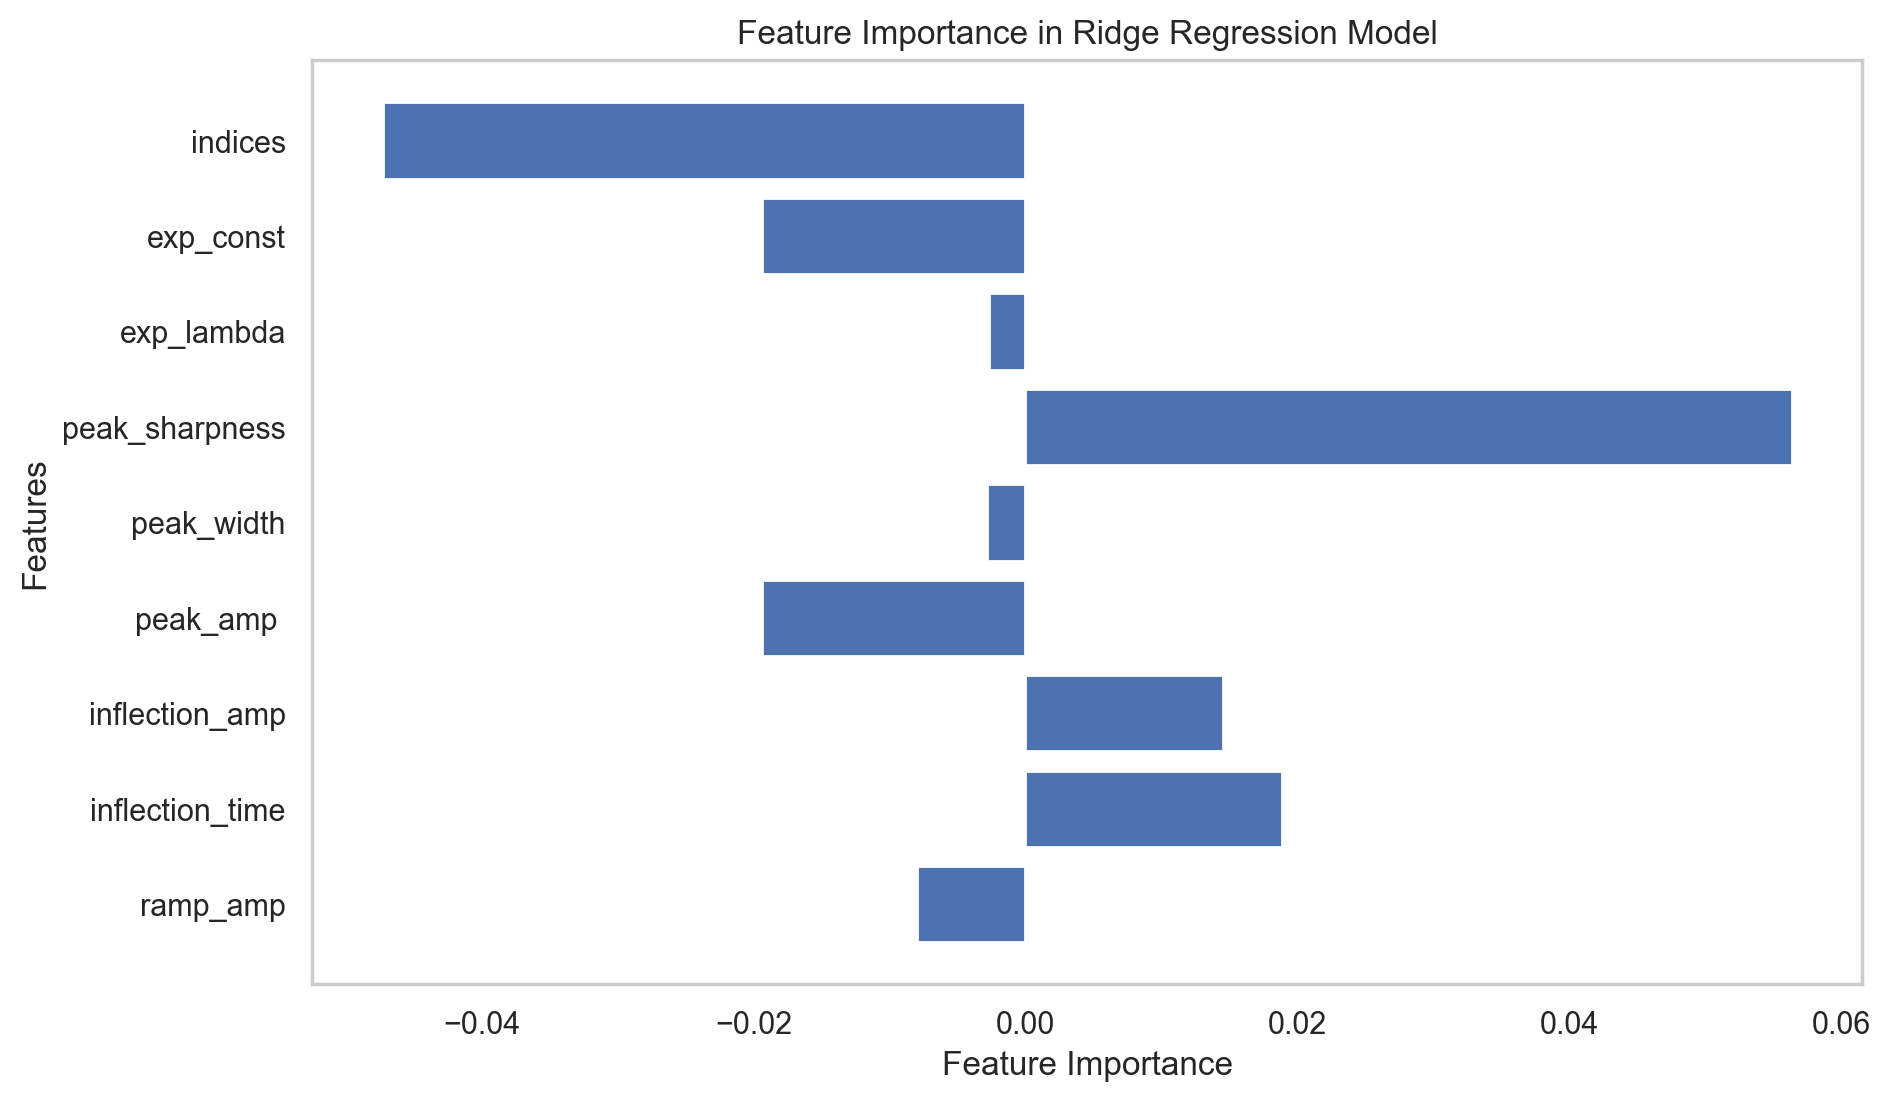

In [52]:
# Visualization of predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # 45-degree line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

# Visualization of residuals
residuals = y_test - predictions
plt.figure(figsize=(10, 6))
plt.scatter(predictions, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.show()

# Feature importance
feature_importance = model.coef_

actual_feature_names = ['ramp_amp', 'inflection_time', 	'inflection_amp', 	'peak_amp ',	'peak_width', 	'peak_sharpness', 	'exp_lambda', 	'exp_const', 'indices']  # replace with your actual feature names

plt.figure(figsize=(10, 6))
plt.barh(np.arange(len(feature_importance)), feature_importance)
plt.yticks(np.arange(len(feature_importance)), actual_feature_names )  # Replace with actual feature names
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Ridge Regression Model')
plt.show()
